# NiCo-Wrapper Vignette — End-to-End Spatial Transcriptomics Analysis

This notebook walks you through the complete **NiCo-Wrapper** analysis pipeline, from raw `.h5ad` inputs to covariation analysis. It is designed as a self-contained vignette that you can adapt to your own data.

**Workflow overview:**

| Step | Description |
|------|-------------|
| 1. Preprocessing | Normalise and align the reference scRNA-seq data and the query spatial transcriptomis data |
| 2. Label transfer | Map reference cell-type annotations from the reference scRNAseq data onto the spatial transcriptomics data |
| 3. Niche interaction analysis | Identify spatially enriched cell-type neighbourhoods |
| 4. Covariation analysis | Discover gene programmes that co-vary across niches |

> **Tip:** Every section contains a *"What to expect"* block explaining what outputs are produced and what to inspect before moving on.

## 1. Import Required Libraries

We start by importing everything that is needed throughout the notebook.

- **`nico_wrapper`** — the package that wraps NiCo's Python API into structured, reproducible pipeline functions.
- **`pathlib.Path`** — used to build platform-independent file paths.
- **`pprint`** — handy for inspecting result dictionaries.

If any import fails, make sure the package is installed in your environment:

```bash
pip install nico-wrapper
# or, if working inside the repo:
pip install -e .
```

In order to run this notebook on jupyter, install also `notebook` and `jupyter` packages into your environment

```bash
pip install notebook jupyter
```

In [1]:
from pathlib import Path
from pprint import pprint

# nico_wrapper pipeline entry-points
from nico_wrapper.preprocess import preprocess_nico_inputs
from nico_wrapper.transfer import (
    run_label_transfer,
    find_anchors,
    transfer_labels,
    save_transfer_result,
)
from nico_wrapper.niche import (
    run_niche_interactions,
    load_niche_result,
    export_interaction_table,
    summarize_niche_result,
)
from nico_wrapper.covariation import (
    run_covariation,
    load_covariation_result,
    export_regression_table,
)

# Configuration dataclasses (optional — only needed if you want to customise defaults)
from nico_wrapper.preprocess.config import NiCoSCTransformConfig, PearsonResidualsConfig
from nico_wrapper.transfer.config import (
    LabelTransferConfig,
    AnchorConfig,
    AnnotationConfig,
    TieStrategy,
)
from nico_wrapper.niche.config import (
    NicheInteractionConfig,
    NeighborhoodConfig,
    InteractionModelConfig,
)
from nico_wrapper.covariation.config import CovariationConfig

print("All imports successful.")

All imports successful.


## 2. Load Initial Dataset

NiCo-Wrapper accepts two `.h5ad` files as starting points:

| File | Content |
|------|---------|
| **Reference** | scRNA-seq AnnData with known cell-type labels stored in the `.obs` slot |
| **Spatial / query** | Spatial transcriptomics AnnData with coordinates in `.obsm["spatial"]` slot|

Edit the paths in the cell below to point to your own data. The `spatial_key` and `ref_label_key` variables tell the pipeline where to find the coordinates and reference labels respectively.

> **Dataset requirements:**
> - Both files should share a common gene space (or a large overlap).
> - The reference `.obs` column named by `ref_label_key` must contain the cell-type annotation in the reference data that you want to use for label transfer.
> - Spatial coordinates must be stored under an `.obsm` key (default: `"spatial"`).

In [ ]:
# ── Dataset paths ──────────────────────────────────────────────────────────────
# Replace these with the actual paths to your .h5ad files.

REFERENCE_H5AD  = Path("data/reference_raw.h5ad")   # reference scRNA-seq data
SPATIAL_H5AD    = Path("data/spatial_raw.h5ad")      # spatial / query data

# ── Key column names ────────────────────────────────────────────────────────────
SPATIAL_KEY   = "spatial"    # .obsm key holding XY coordinates in the spatial file
REF_LABEL_KEY = "cluster"    # .obs column holding cell-type labels in the reference data

# ── Output directories ──────────────────────────────────────────────────────────
REF_OUT_DIR     = Path("inputRef")      # preprocessed reference data outputs
SPATIAL_OUT_DIR = Path("inputQuery")    # preprocessed spatial data outputs
ANALYSIS_DIR    = Path("nico_analysis") # all downstream outputs live here

# Quick sanity check
for p in [REFERENCE_H5AD, SPATIAL_H5AD]:
    if not p.exists():
        print(f"[WARNING] File not found: {p}  — update the path before running.")
    else:
        print(f"[OK] Found: {p}")

## 3. Data Exploration

Before running the pipeline it is good practice to inspect the raw inputs and confirm that:

1. Cell counts and gene counts look reasonable.
2. The spatial coordinate key exists in `.obsm`.
3. The reference label key exists in `.obs` and contains the expected cell types.

Run the cell below to get a quick overview of both AnnData objects.

In [6]:
import anndata as ad

# Load both files for inspection (read-only)
ref_adata     = ad.read_h5ad(REFERENCE_H5AD)
spatial_adata = ad.read_h5ad(SPATIAL_H5AD)

print("=== Reference AnnData ===")
print(ref_adata)
print(f"\n  Available .obs columns : {list(ref_adata.obs.columns)}")
print(f"  Label key '{REF_LABEL_KEY}' present: {REF_LABEL_KEY in ref_adata.obs.columns}")
if REF_LABEL_KEY in ref_adata.obs.columns:
    print(f"  Cell types ({ref_adata.obs[REF_LABEL_KEY].nunique()}): "
          f"{sorted(ref_adata.obs[REF_LABEL_KEY].unique().tolist())}")

print("\n=== Spatial AnnData ===")
print(spatial_adata)
print(f"\n  Available .obsm keys   : {list(spatial_adata.obsm.keys())}")
print(f"  Spatial key '{SPATIAL_KEY}' present: {SPATIAL_KEY in spatial_adata.obsm}")

# Shared gene overlap
shared = set(ref_adata.var_names) & set(spatial_adata.var_names)
print(f"\nShared genes: {len(shared)} / ref {ref_adata.n_vars} / spatial {spatial_adata.n_vars}")

=== Reference AnnData ===
AnnData object with n_obs × n_vars = 2239 × 32287
    obs: 'cluster'

  Available .obs columns : ['cluster']
  Label key 'cluster' present: True
  Cell types (19): ['BZE', 'Blood vasc.', 'Cycling/GC B cell', 'Glial', 'Goblet', 'Lymphatic', 'MZE', 'Macrophage', 'Paneth', 'Plasma', 'Rest B', 'Stem/TA', 'Stroma', 'T cell', 'TZE', 'Tuft', 'cDC/monocyte', 'neurons/enteroendocrine', 'pDC']

=== Spatial AnnData ===
AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    obsm: 'spatial'

  Available .obsm keys   : ['spatial']
  Spatial key 'spatial' present: True

Shared genes: 240 / ref 32287 / spatial 241


## 4. Preprocessing

`preprocess_nico_inputs` takes both raw `.h5ad` files and produces three different outputs, that are used for downstream steps:

| Output key | File | Description |
|------------|------|-------------|
| `original_counts` | `Original_counts.h5ad` | Reference data with raw counts + optionally UMAP |
| `sct_single_cell` | `sct_singleCell.h5ad` | SCTransform-normalised reference data |
| `sct_spatial` | `sct_spatial.h5ad` | SCTransform-normalised spatial transcriptomics data |

**Key parameters to tune:**

- `normalization` — Switch between `NiCoSCTransformConfig()` (default, analogous to Seurat's SCTransform) and `PearsonResidualsConfig()` for Pearson-residual normalisation.
- `gene_space` — `"shared"` retains only genes present in both datasets; `"reference_all"` keeps all reference genes.
- `leiden_resolutions` — A list of resolutions for unsupervised clustering of the spatial transcriptomics data. Inspect the clustered UMAP afterwards to decide which resolution best separates tissue regions.
- `ref_min_cell_counts` / `ref_min_gene_cells` — Quality-control thresholds applied to the reference scRNAseq dataset. Cells with less than `ref_min_cell_counts` UMI counts (default is 5) and genes with less than `ref_min_gene_cells` (defualt is 1) are removed.
- `spatial_min_cell_counts` / `spatial_min_gene_cells` — Quality-control thresholds applied to the spatial transcriptomics data. Similar to the reference scRNAseq thresholds.
    > **Note:** in case of facing errors for getting `NaN` or `-Inf` values during the normalization step, increase the filtering thresholds
- `overwrite` — `False` (default) to avoid re-computing the same function; `True` will overwrite existing files.

> **What to expect:** Two output directories (`inputRef/`, `inputQuery/`) are created, each containing the processed `.h5ad` files. Additionally, the function returns a dictionary of `Path` objects for downstream use.

In [ ]:
preprocess_outputs = preprocess_nico_inputs(
    REFERENCE_H5AD,
    SPATIAL_H5AD,
    # ── Output directories ───────────────────────────────────────────────────
    ref_out_dir=REF_OUT_DIR,
    spatial_out_dir=SPATIAL_OUT_DIR,
    # ── Key names ────────────────────────────────────────────────────────────
    spatial_key=SPATIAL_KEY,
    ref_label_key=REF_LABEL_KEY,
    # ── Normalisation ────────────────────────────────────────────────────────
    normalization=NiCoSCTransformConfig(),   # swap for PearsonResidualsConfig() if preferred
    # ── QC thresholds ────────────────────────────────────────────────────────
    ref_min_cell_counts=5,
    ref_min_gene_cells=1,
    spatial_min_cell_counts=5,
    spatial_min_gene_cells=1,
    # ── Gene space ───────────────────────────────────────────────────────────
    #gene_space="shared",                     # "shared" | "reference_all"
    gene_space="reference_all",                     # for the comparisson run with original nico
    # ── Spatial clustering ───────────────────────────────────────────────────
    spatial_n_pcs=30,
    leiden_resolutions=[0.4, 0.5],
    # ── Misc ─────────────────────────────────────────────────────────────────
    make_reference_umap=True,
    random_state=0,
    overwrite=True,                         # set True to recompute existing files
)

print("Preprocessing outputs:")
pprint(preprocess_outputs)

Preprocessing outputs:
{'original_counts': PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/inputRef/Original_counts.h5ad'),
 'sct_single_cell': PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/inputRef/sct_singleCell.h5ad'),
 'sct_spatial': PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/inputQuery/sct_spatial.h5ad')}


## 5. Label Transfer

Cell-type labels from the reference data are propagated onto the spatial transcriptomics data in two sub-steps:

1. **Anchor discovery** (`find_anchors`) — Identifies mutual nearest-neighbour (MNN) anchor pairs between the reference data and the spatial transcriptomics data in PCA space. These anchors bridge the two modalities.
2. **Label propagation** (`transfer_labels`) — For each mutual nearest neighbor pair, it transfers cell-type labels from the reference scRNAseq data into the spatial cells. For unmapped spatial cells, it goes through an iterative process, where it tries to assign a label based on majority vote (default option) or by a weighted score (see parameters to tune).
3. **Save** (`save_transfer_result`) — Writes the annotated spatial AnnData (with a new `.obs` column) to disk.

Optionally, use `run_label_transfer` to run all three steps at once (shown below as a convenience wrapper).

**Key parameters to tune:**

- `AnchorConfig.neighbors` *(default: `50`)* — Number of MNN neighbours used for anchor discovery. Higher values create more robust but potentially over-smoothed anchors.
- `AnnotationConfig.iterations` *(default: `3`)* — Number of iterative rounds used to propagate labels from anchored to unmapped spatial cells; more iterations increase smoothing.
- `AnnotationConfig.tie_strategy` *(default: `"majority"`)* — How to resolve ties when multiple labels have equal probability. `"majority"` uses a simple majority vote; `"weighted"` uses weighted nearest-neighbour voting.

> **What to expect:** A new file `nico_celltype_annotation.h5ad` is written to `nico_analysis/`. The transferred labels are stored in `.obs["nico_ct"]`. Inspect the label distribution to verify that the transfer looks biologically reasonable before proceeding.
>
> Additionally, `run_label_transfer` returns a `TransferOutputs` dataclass holding the following fields:
>
> | Field | Description |
> |-------|-------------|
> | `annotated_h5ad` | Path to the annotated spatial `.h5ad` with transferred labels in `.obs["nico_ct"]` |
> | `anchors_npz` | Path to the `.npz` file of MNN anchor pairs (`None` if cleanup was enabled) |
> | `output_dir` | Base output directory passed to the pipeline |
> | `annotation_dir` | Directory containing anchor/annotation intermediates |
> | `iteration_cluster_csvs` | Per-iteration cluster assignment CSVs |
> | `iteration_celltype_csvs` | Per-iteration cell-type probability CSVs |
>
> Access any field with standard dot notation, e.g. `transfer_outputs.annotated_h5ad`.

In [ ]:
transfer_outputs = run_label_transfer(
    REF_OUT_DIR,
    SPATIAL_OUT_DIR,
    output_dir=ANALYSIS_DIR,
    config=LabelTransferConfig(
        anchors=AnchorConfig(
            neighbors=50,       # number of MNN neighbours for anchor discovery and KNN graph
        ),
        annotation=AnnotationConfig(
            spatial_cluster_key="leiden0.4", #default is leiden0.5
            iterations=3,                 # label-propagation rounds
            tie_strategy="majority",      # "majority" (default) | "weighted"
        ),
        overwrite=True
    ),
)

print("Label transfer outputs:")
print(f"  Annotated h5ad : {transfer_outputs.annotated_h5ad}")
print(f"  Anchor file    : {transfer_outputs.anchors_npz}")

# ── Optional: inspect transferred label distribution ─────────────────────────
annotated = ad.read_h5ad(transfer_outputs.annotated_h5ad)
label_counts = annotated.obs["nico_ct"].value_counts()
print("\nTransferred label distribution:")
print(label_counts.to_string())

Label transfer outputs:
  Annotated h5ad : /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/nico_celltype_annotation.h5ad
  Anchor file    : /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/annotations/anchors_data_50.npz

Transferred label distribution:
nico_ct
BZE                        1786
Lymphatic                  1405
Stem/TA                     992
Goblet                      449
Plasma                      440
T cell                      437
Macrophage                  350
TZE                         318
Stroma                      269
NM                          234
Paneth                      183
Blood vasc.                 152
Glial                        95
MZE                          77
cDC/monocyte                 73
Rest B                       46
neurons/enteroendocrine      43
Tuft                         40
pDC                          15
Cycling/GC B cell            12


## 6. Niche Interaction Analysis

With cell-type labels on the spatial transcriptomics data, NiCo can now model the **spatial neighbourhood composition** around each cell and learn which cell-types are enriched within local neighborhoods.

Internally, NiCo builds a logistic-regression model per reference cell type where the predictor is the neighbourhood composition vector. The regression coefficients encode directed interaction strengths between cell types.

**Key parameters to tune:**

- `NeighborhoodConfig.radius` *(default: `0`)* — Neighbourhood mode. If `radius=0`, NiCo's Delaunay-neighbourhood mode (automatic) is used; otherwise, a positive value sets a fixed spatial radius.
- `InteractionModelConfig.c_values` *(default: `None`)* — Candidate inverse regularisation strengths for the logistic regression. If `None`, the function uses NiCo's default grid and selects the best via cross-validation; pass e.g. `(1.0,)` to fix a single value and skip CV.
- `InteractionModelConfig.n_jobs` *(default: `-1`)* — Number of parallel jobs; `-1` uses all available CPUs.

**Outputs written to disk:**

- `niche_prediction/` — Model classifier matrices (`.npz`) and a summary manifest.
- Optional plots of spatial cell-type maps.

> **What to expect:** The function returns a `NicheInteractionResult` object. Call `summarize_niche_result` to see a compact overview of the artifacts. Run `export_interaction_table` to produce a TSV of signed interaction coefficients that you can load into downstream analyses or visualisation tools.

In [ ]:
niche_result = run_niche_interactions(
    ANALYSIS_DIR,
    config=NicheInteractionConfig(
        neighborhood=NeighborhoodConfig(
            radius=0,           # 0 = Delaunay neighbourhood (automatic); positive value = fixed radius
            additional_excluded_cell_types=("Basophils", "Cycling/GC B cell", "pDC"), #Added for the comparisson run with original nico. Cells removed given they have low abundance
        ),
        model=InteractionModelConfig(
            # c_values is chosen automatically via cross-validation;
            # pass c_values=(1.0,) to fix a single value and skip CV
        ),
        overwrite=True
    ),
)

print("Niche interaction result summary:")
pprint(summarize_niche_result(niche_result))

# ── Export directed interaction coefficients to TSV ──────────────────────────
interaction_table_path = export_interaction_table(
    niche_result,
    cutoff=0.0,              # only keep positive (enriched) interactions
    include_self_edges=True,
)
print(f"\nInteraction table written to: {interaction_table_path}")

average neighbors: 4.76701607267645
average distance: 64.23323332451093
data shape (7124, 19) (7124,) neighbor shape (7124, 17)
Searching hyperparameters  Grid method: 0.015625
Searching hyperparameters  Grid method: 0.015625
Inverse of lambda regularization found 0.015625
training (5700, 17) testing (1424, 17) coeff (17, 17)
Niche interaction result summary:
{'annotated_h5ad': PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/nico_celltype_annotation.h5ad'),
 'classifier_matrices_npz': PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/classifier_matrices_0.npz'),
 'covariation_ready': True,
 'interactions_tsv': PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/interactions_0.tsv'),
 'manifest_json': PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/niche_manifest_0.json'),
 'metrics_tsv': PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_a

## 7. Covariation Analysis

Covariation analysis identifies **latent gene programmes** (factors) that co-vary across cell-types enriched within local niches and discovered in the previous step. Mathematically, NiCo factorises a joint expression matrix using ridge regression to score each factor's contribution to the niche.

Two modalities are available:

| Modality | Description |
|----------|-------------|
| `"double"` | Uses both reference (single-cell) and spatial expression — recommended |
| `"single"` | Uses only spatial expression |

**Key parameters to tune:**

- `CovariationConfig.n_factors` — Number of latent factors (analogous to the number of components in NMF). Start with 3–5 and increase if the residuals remain high.
- `CovariationConfig.modality` — `"double"` or `"single"` (see table above).
- `CovariationConfig.ridge_coef_cutoff` — Minimum absolute coefficient for a gene–factor association to be exported.

**Outputs written to disk:**

- `covariation/` — Factor matrices, a state pickle (for re-loading without rerunning), and an optional TSV of ridge coefficients.

> **What to expect:** A `CovariationResult` is returned containing the path to the covariation directory. Call `export_regression_table` to get a long-format TSV with columns `factor`, `gene`, and `coefficient` that you can directly import into R or Python for downstream gene-set enrichment analysis.

In [ ]:
covariation_result = run_covariation(
    niche_result=niche_result,      # pass the in-memory result from the previous step
    ref_dir=REF_OUT_DIR,            # required for "double" modality
    spatial_dir=SPATIAL_OUT_DIR,    # required for "double" modality
    config=CovariationConfig(
        n_factors=3,                # number of latent factors; tune based on your data
        modality="double",          # "double" (recommended) | "single"
        ridge_coef_cutoff=0.0,      # export threshold for the regression table
        overwrite=True
    ),
)

print(f"Covariation directory: {covariation_result.covariation_dir}")

# ── Export ridge-regression coefficients to TSV ──────────────────────────────
regression_table_path = export_regression_table(covariation_result)
print(f"Regression table written to: {regression_table_path}")


common genes between sc and sp 203 203


 Spatial and scRNA-seq number of clusters, respectively  17 19
Common cell types between spatial and scRNA-seq data   17 {'cDC/monocyte', 'neurons/enteroendocrine', 'T cell', 'Goblet', 'Blood vasc.', 'Stroma', 'Glial', 'MZE', 'Paneth', 'Plasma', 'Stem/TA', 'Tuft', 'Macrophage', 'TZE', 'Lymphatic', 'Rest B', 'BZE'}

The spatial cluster name does not match the scRNA-seq cluster name  set()
If the above answer is Null, then everything is okay. However, if any spatial cell type does not exist in the scRNA-seq data, please correct this manually; otherwise, NiCo will not run. 



Blood vasc. alpha, H size, W size, spH size: 8 (3, 33) (58, 3) (3, 152)
Glial alpha, H size, W size, spH size: 4 (3, 10) (44, 3) (3, 95)
Goblet alpha, H size, W size, spH size: 4 (3, 216) (128, 3) (3, 449)
MZE alpha, H size, W size, spH size: 30 (3, 63) (56, 3) (3, 77)
Macrophage alpha, H size, W size, spH size: 16 (3, 89) (113, 3) (3, 350)
Plasma alpha, H size, W size, spH s

## 8. Re-loading Results Without Rerunning

If you close this notebook and want to re-inspect results later, run the cell below — no recomputation is needed for most variables.

**Variables re-created by the cell below:**

| Variable | How it is restored |
|---|---|
| `niche_result` | `load_niche_result()` — reads from disk, no recomputation |
| `covariation_result` | `load_covariation_result()` — reads from disk, no recomputation |
| `transfer_outputs` | Manually reconstructed as a `TransferOutputs` dataclass from known paths |
| `interaction_table_path` | Re-exported from `niche_result` (file already on disk, very fast) |
| `regression_table_path` | Re-exported from `covariation_result` (file already on disk, very fast) |

In [ ]:
from pathlib import Path
from nico_wrapper.niche import load_niche_result, export_interaction_table
from nico_wrapper.niche.proximity import run_proximity_analysis
from nico_wrapper.niche.config import ProximityConfig
from nico_wrapper.covariation import load_covariation_result, export_regression_table
from nico_wrapper.transfer.config import TransferOutputs

# ── Output directories (must match what was used when the pipeline ran) ───────
ANALYSIS_DIR    = Path("working_dir/nico_analysis")
REF_OUT_DIR     = Path("working_dir/inputRef")
SPATIAL_OUT_DIR = Path("working_dir/inputQuery")

# ── Pipeline parameters (must match the original run) ─────────────────────────
SPATIAL_KEY = "spatial"
RADIUS      = 0
N_FACTORS   = 3

# ── 1. Niche interaction result ───────────────────────────────────────────────
niche_result = load_niche_result(ANALYSIS_DIR, radius=RADIUS)
print(f"niche_result loaded: prediction_dir = {niche_result.prediction_dir}")

# ── 2. Interaction table (already on disk; re-export is instant) ───────────────
interaction_table_path = export_interaction_table(
    niche_result,
    cutoff=0.0,
    include_self_edges=True,
)
print(f"interaction_table_path: {interaction_table_path}")

# ── 3. Covariation result ─────────────────────────────────────────────────────
covariation_result = load_covariation_result(
    ANALYSIS_DIR,
    radius=RADIUS,
    n_factors=N_FACTORS,
    load_state=True,   # loads the NiCo state pickle so report functions work
)
print(f"covariation_result loaded: covariation_dir = {covariation_result.covariation_dir}")

# ── 4. Regression table (already on disk; re-export is instant) ───────────────
regression_table_path = export_regression_table(covariation_result)
print(f"regression_table_path: {regression_table_path}")

# ── 5. Transfer outputs (no serialiser exists — reconstruct from known paths) ─
_annotation_dir = ANALYSIS_DIR / "annotations"
_annotated_h5ad = ANALYSIS_DIR / "nico_celltype_annotation.h5ad"

transfer_outputs = TransferOutputs(
    output_dir=ANALYSIS_DIR,
    annotation_dir=_annotation_dir,
    annotated_h5ad=_annotated_h5ad,
    anchors_npz=None,
    iteration_cluster_csvs=tuple(sorted(_annotation_dir.glob("iteration_*_cluster*.csv"))) if _annotation_dir.exists() else (),
    iteration_celltype_csvs=tuple(sorted(_annotation_dir.glob("iteration_*_celltype*.csv"))) if _annotation_dir.exists() else (),
)
print(f"transfer_outputs.annotated_h5ad: {transfer_outputs.annotated_h5ad}")

print("\nAll previous variables are ready.")

## 9. Visualization

The cells below produce complementary visualisations to help you interpret the results, based on different steps of the analysis

- Spatial and UMAP plots
- Niche Interaction plots
- Covariation analysis plots

### Spatial and UMAP plots

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/annotations/tissue_and_umap_with_all_celltype_annotations.pdf


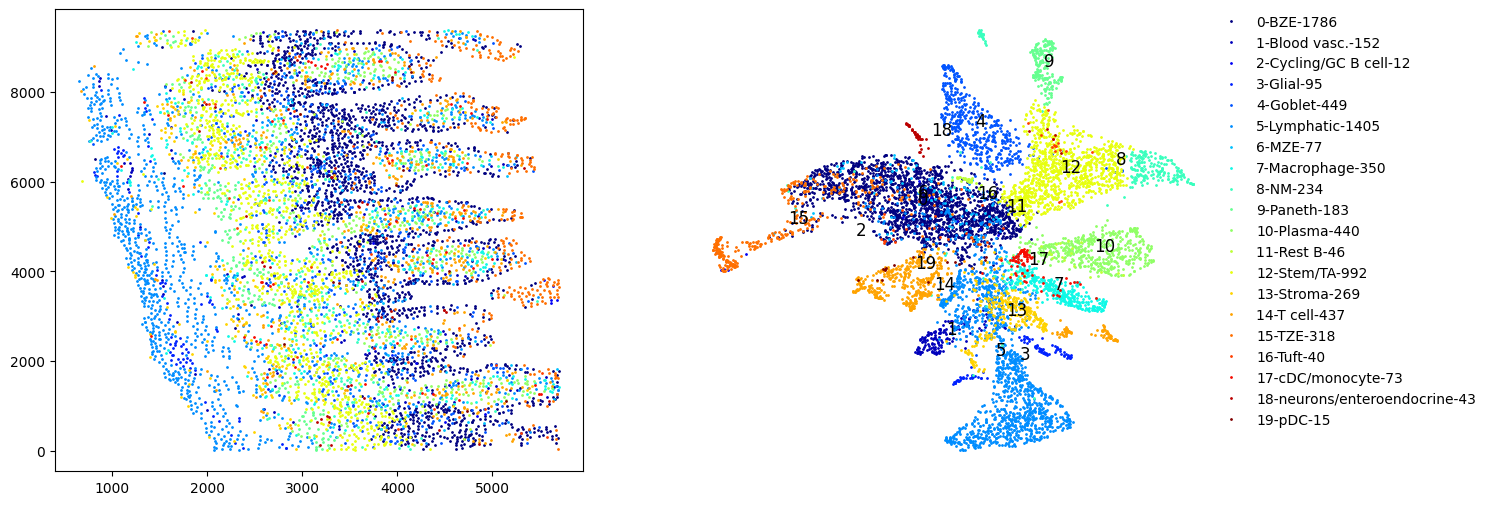

In [ ]:
#The spatial / UMAP annotation plots require functions from the original nico package (already installed)
import nico
from nico import Annotations as sann

# sann.visualize_umap_and_cell_coordinates_with_all_celltypes expects:
#   output_nico_dir       → the base analysis directory (trailing slash)
#   output_annotation_dir → the annotations subdirectory (trailing slash)
#   anndata_object_name   → just the filename of the annotated .h5ad

sann.visualize_umap_and_cell_coordinates_with_all_celltypes(
    output_nico_dir=str(transfer_outputs.output_dir) + "/",
    output_annotation_dir=str(transfer_outputs.annotation_dir) + "/",
    anndata_object_name=transfer_outputs.annotated_h5ad.name,
    spatial_cluster_tag="nico_ct",
    spatial_coordinate_tag="spatial",
    umap_tag="X_umap",
    showit=True,
    transparent_mode=False,
)

[['Stem/TA', 'Paneth'], ['Paneth', 'Goblet']]
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/annotations/fig_individual_annotation/Stem_TA0.pdf
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/annotations/fig_individual_annotation/Paneth1.pdf


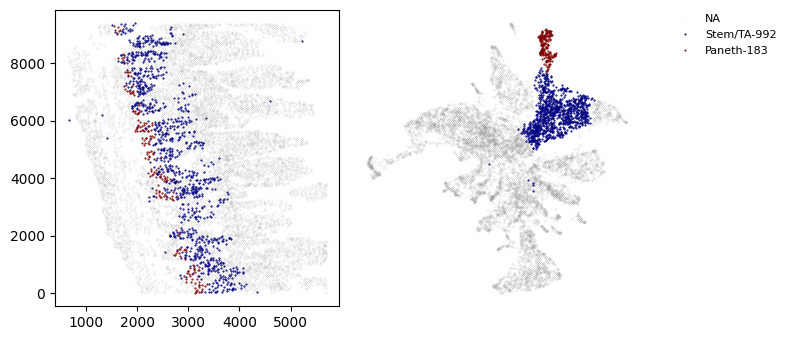

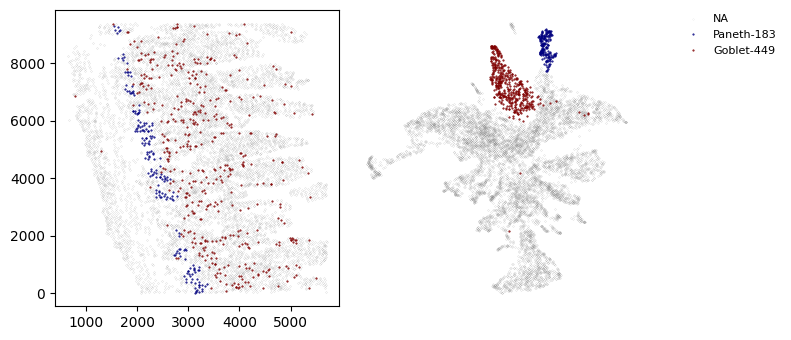

In [10]:
#Visualize spatial annotation of specific cell types
choose_celltypes=[['Stem/TA','Paneth'],['Paneth','Goblet']]

sann.visualize_umap_and_cell_coordinates_with_selected_celltypes(
choose_celltypes=choose_celltypes,    
output_nico_dir=str(transfer_outputs.output_dir) + "/",
output_annotation_dir=str(transfer_outputs.annotation_dir) + "/",
anndata_object_name=transfer_outputs.annotated_h5ad.name,
spatial_cluster_tag="nico_ct",
spatial_coordinate_tag='spatial',
umap_tag='X_umap',
showit=True,transparent_mode=False)

### Interaction plots

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/Niche_interactions_without_edge_weights_R0.pdf


[PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/Niche_interactions_without_edge_weights_R0.pdf')]

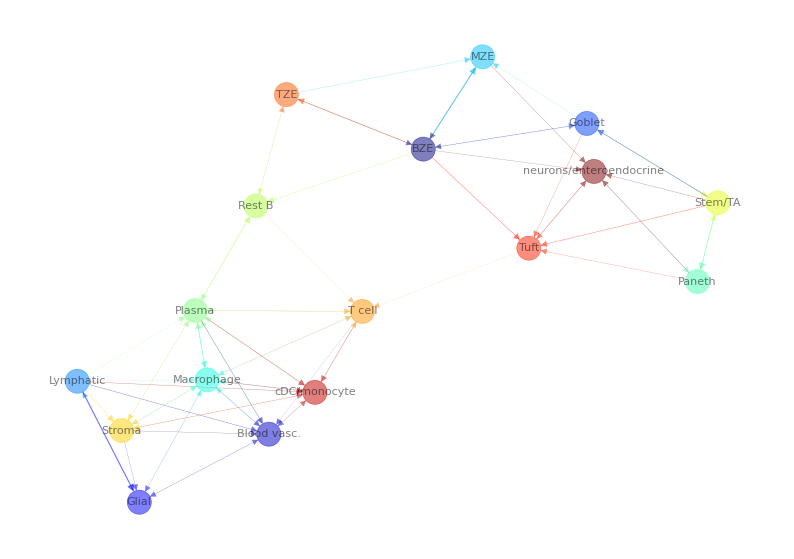

In [ ]:
# Plot the niche interaction network without edge weights
# Uses plot_niche_result with kind="graph", which calls
# sint.plot_niche_interactions_without_edge_weight internally.

from nico_wrapper.niche import NichePlotConfig
from nico_wrapper.niche.plotting import plot_niche_result, _to_nico_plot_namespace

plot_niche_result(
    niche_result,
    config=NichePlotConfig(
        kinds=("graph",),
        interaction_cutoff=0.1,
        graph_edge_labels=False,   # True → show coefficient values on edges
        show=True,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/Niche_interactions_with_edge_weights_R0.pdf


[PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/Niche_interactions_with_edge_weights_R0.pdf')]

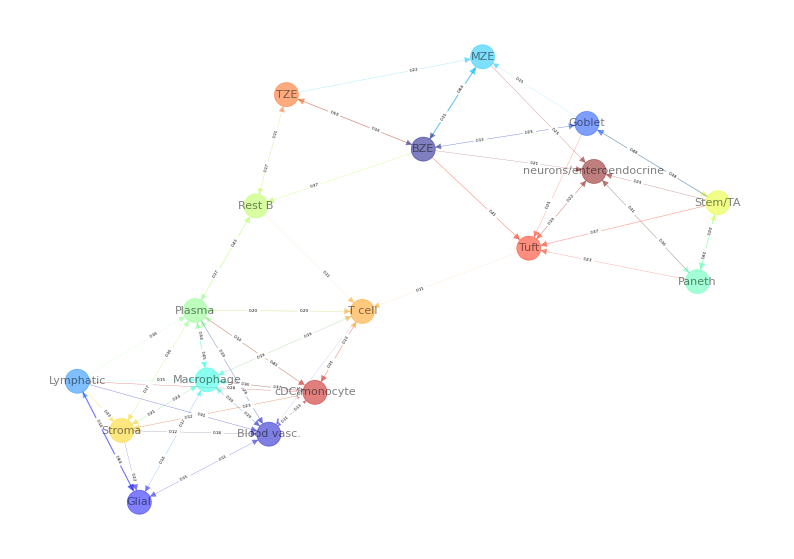

In [14]:
# Plot the niche interaction network with edge weights
# Set graph_edge_labels=True
plot_niche_result(
    niche_result,
    config=NichePlotConfig(
        kinds=("graph",),
        interaction_cutoff=0.1,
        graph_edge_labels=True,   # True → show coefficient values on edges
        show=True,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/TopCoeff_R0/Rank1_Paneth.pdf
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/TopCoeff_R0/Rank3_Stem_TA.pdf


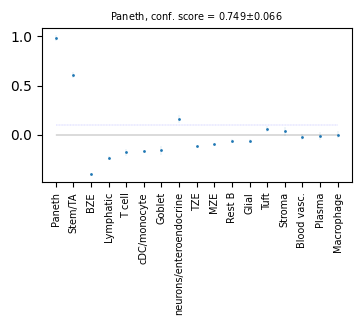

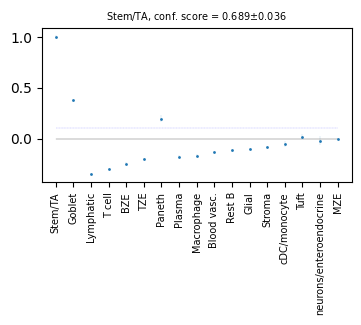

In [ ]:
# Interaction coefficients for selected source cell types
from nico_wrapper.niche import NichePlotConfig
from nico_wrapper.niche.plotting import plot_niche_result, _to_nico_plot_namespace

celltype_niche_interaction_cutoff = 0.1

# plot_niche_result supports choose_celltypes for the "top-coefficients" kind.
# Pass an empty tuple (default) to plot all cell types, or list specific ones to filter.

# Option A — all cell types
#plot_niche_result(
#    niche_result,
#    config=NichePlotConfig(
#        kinds=("top-coefficients",),
#        interaction_cutoff=celltype_niche_interaction_cutoff,
#        show=True,
#    ),
#)

# Option B — selected cell types only
plot_niche_result(
    niche_result,
    config=NichePlotConfig(
        kinds=("top-coefficients",),
        interaction_cutoff=celltype_niche_interaction_cutoff,
        choose_celltypes=("Stem/TA", "Paneth"),   # ← leave empty tuple for all
        show=True,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/Confusing_matrix_R0.pdf


[PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/Confusing_matrix_R0.pdf')]

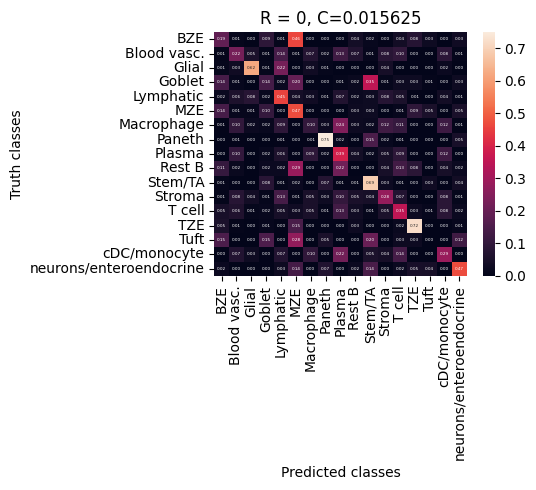

In [ ]:
# Plot the average confusion matrix of the classifier from cross-folds
#It compares the predicted cell type label of the logistic regression with the ground truth label corresponding to the NiCo annotation
plot_niche_result(
    niche_result,
    config=NichePlotConfig(
        kinds=("confusion",),
        show=True,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/weight_matrix_R0.pdf


[PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/weight_matrix_R0.pdf')]

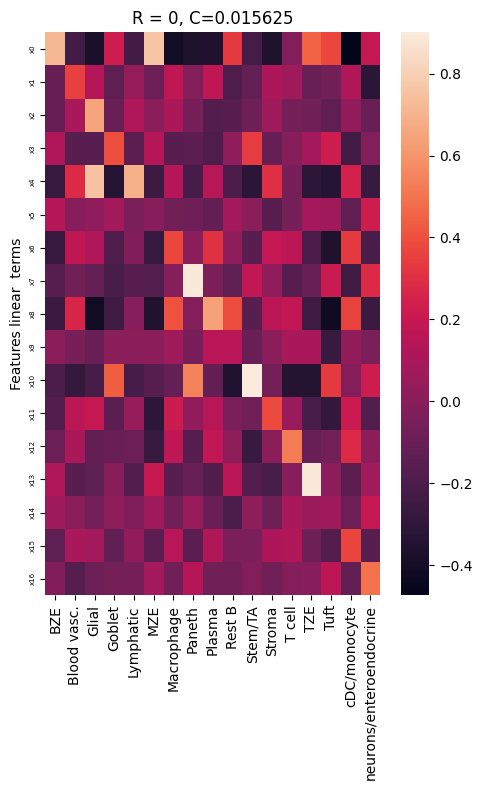

In [18]:
# Plot the average coefficient matrix of the classifier from cross-folds
plot_niche_result(
    niche_result,
    config=NichePlotConfig(
        kinds=("coefficients",),
        show=True,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/scores_0.pdf


[PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/scores_0.pdf')]

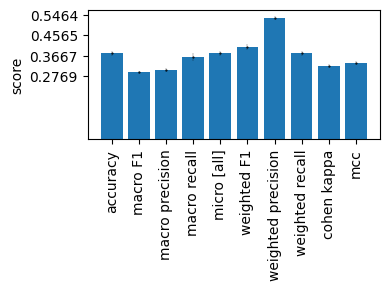

In [19]:
# Plot the evaluation score of the classifier for different metrics
plot_niche_result(
    niche_result,
    config=NichePlotConfig(
        kinds=("scores",),
        show=True,
    ),
)

Observed pairs table : /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/proximity_observed_0.tsv
Obs/rand ratio table : /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/proximity_ratio_0.tsv
Plot saved to        : /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/niche_prediction_linear/celltype_proximity_pairs0.png


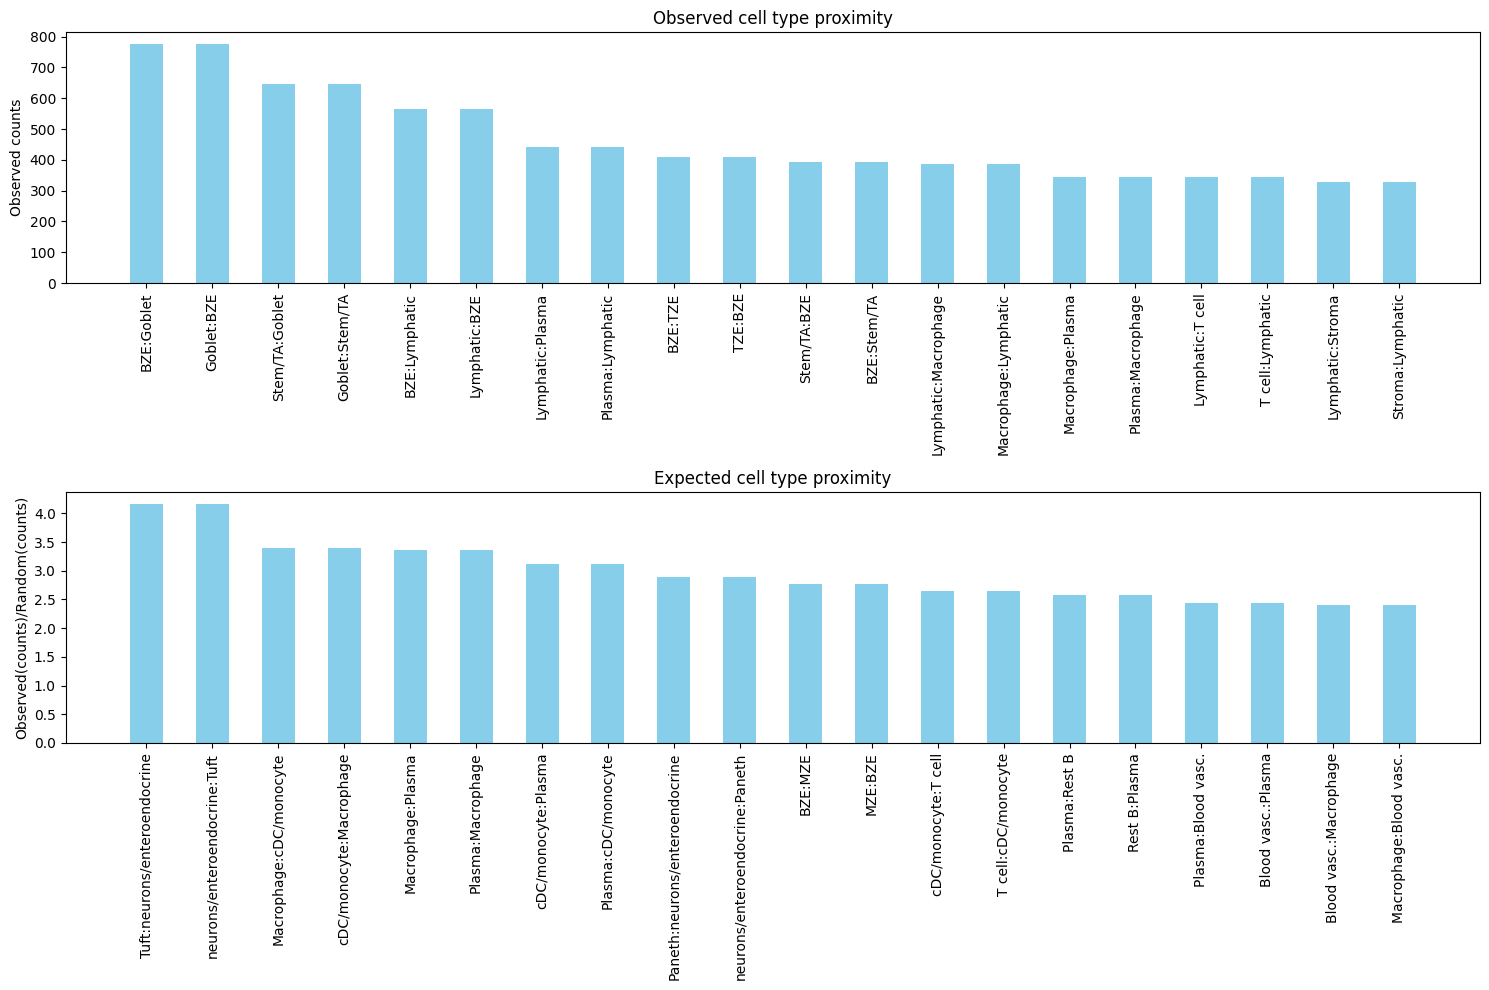

In [ ]:
# Proximity analysis between cell types
from nico_wrapper.niche import ProximityConfig
from nico_wrapper.niche.proximity import run_proximity_analysis

# Visualization of top co-localized cell-type pairs (observed vs. randomized)
proximity_result = run_proximity_analysis(
    niche_result,
    config=ProximityConfig(
        n_permutations=1000,       # number of random permutations for the null distribution
        remove_self_pairs=True,    # exclude same cell-type pairs
        as_counts=True,            # use raw counts (False = use proportions)
        seed=42,                   # for reproducibility
        saveas="png",
        show=True,                 # display the NiCo proximity bar chart inline
    ),
)

print(f"Observed pairs table : {proximity_result.observed_tsv}")
print(f"Obs/rand ratio table : {proximity_result.ratio_tsv}")
print(f"Plot saved to        : {proximity_result.plot_path}")

### Covariation analysis

cell types found  ['Paneth']
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/NMF_output/Paneth.png


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/NMF_output/Paneth.png'),)

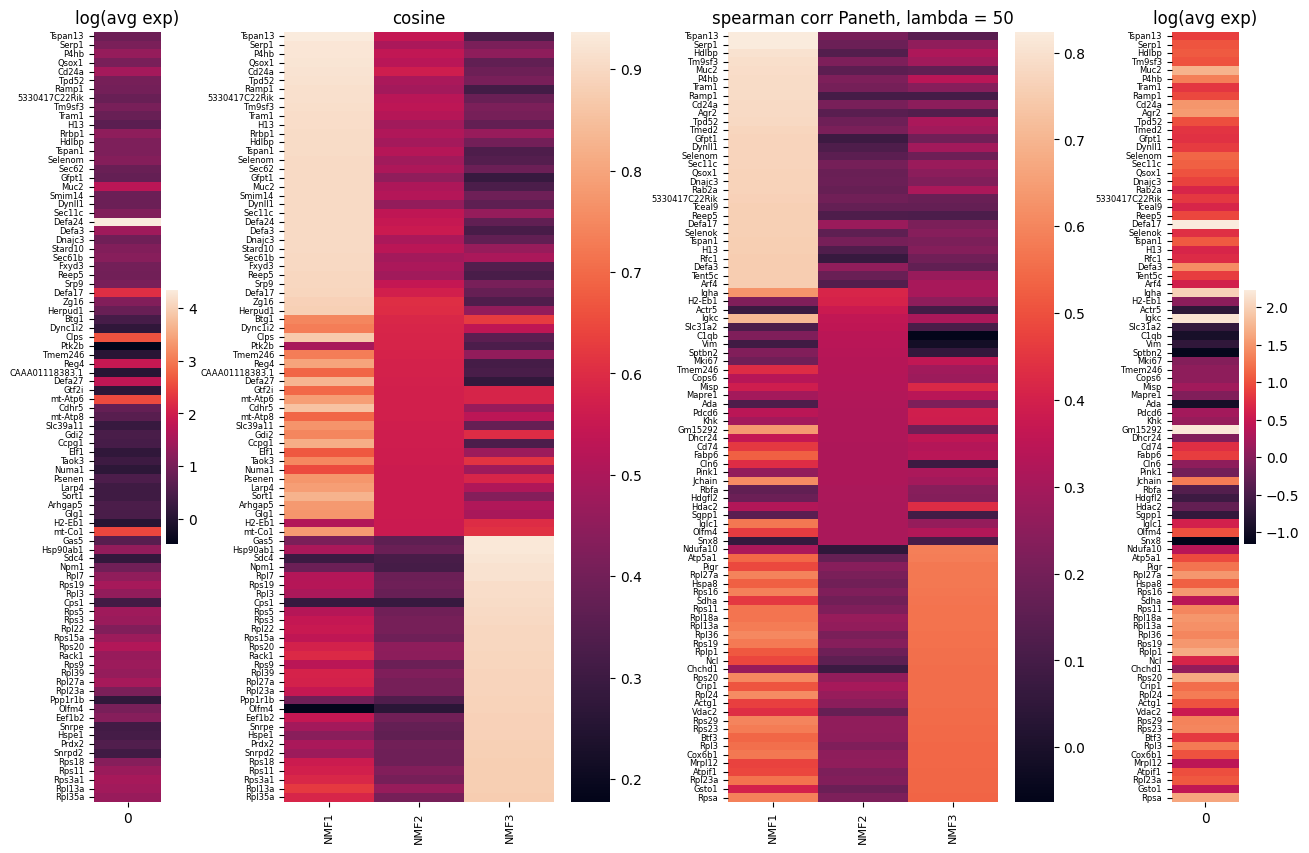

In [23]:
from nico_wrapper.covariation.reports import plot_factor_gene_heatmaps
from nico_wrapper.covariation.config import CovariationReportConfig

# Plot cosine and Spearman correlation to factors for selected cell types
# plot_factor_gene_heatmaps wraps scov.plot_cosine_and_spearman_correlation_to_factors
plot_factor_gene_heatmaps(
    covariation_result,
    config=CovariationReportConfig(
        choose_celltypes=("Paneth",),   # ← cell types to plot; empty tuple = all
        top_genes_per_factor=30,        # NOG_Fa: number of top genes per factor
        correlation_with_spearman=True, # True = Spearman; False = cosine only
        show=True,
        saveas="png",
        dpi=300,
        transparent=False,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Factors_Stem_TA.png


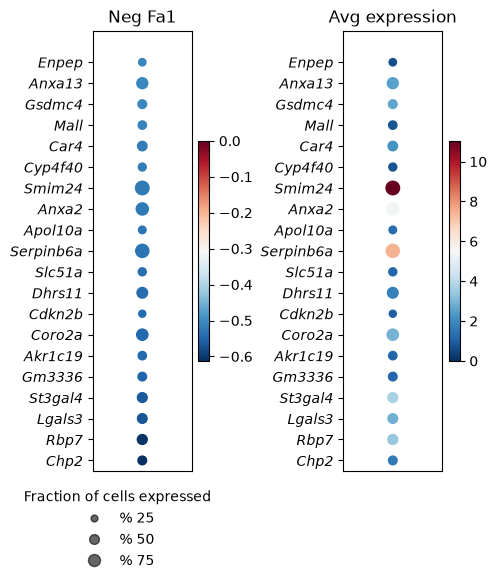

In [ ]:
#Visualizing genes associated with the latent factors along with average expression
from nico_wrapper.covariation.reports import extract_top_genes
from nico_wrapper.covariation.config import CovariationReportConfig

# Extract and plot top genes for a single cell type / factor combination.
# Returns a DataFrame; also saves a TSV next to the covariation outputs.
top_genes_df = extract_top_genes(
    covariation_result,
    cell_type="Stem/TA",
    factor_id=1,
    config=CovariationReportConfig(
        top_genes_per_factor=20,
        organism="mouse",
        include_rps_rpl_mt_genes=True,
        correlation_with_spearman=True,
        positively_correlated=False,
        show=True,
        saveas="png",
        dpi=300,
        transparent=False,
    ),
)

#The top genes are also saved to a TSV file next to the covariation outputs

In [ ]:
#Inspect genes associated with a latent factor
#The table summarizes the positive or negative spearman correlation or cosine similarity with the
# factor, the mean expression and the proportion of cells expressing the gene for the respective cell type.
top_genes_df

,Gene,Fa,mean_expression,proportion_of_population_expressed
0,Chp2,-0.612343,1.619048,0.388095
1,Rbp7,-0.607001,3.402381,0.504762
2,Lgals3,-0.568477,2.847619,0.480952
3,St3gal4,-0.564246,3.750000,0.492857
4,Gm3336,-0.550167,1.152381,0.383333
5,Akr1c19,-0.547283,1.142857,0.359524
6,Coro2a,-0.546213,2.904762,0.657143
7,Cdkn2b,-0.543927,0.973810,0.257143
8,Dhrs11,-0.541752,1.773810,0.585714
9,Slc51a,-0.539230,1.123810,0.333333


Plot linear regression coefficients between factors of the central cell type (y-axis) and factors of niche cell types (x-axis).

Circle size scales with -log10(p-value) (indicated as number on top of each circle). To generate plots for all cell types, leave list argument choose_celltypes empty.

cell types found  ['Stem/TA']
The regression figures as pvalue circle plots are saved in following path  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_coeff_circleplot_*


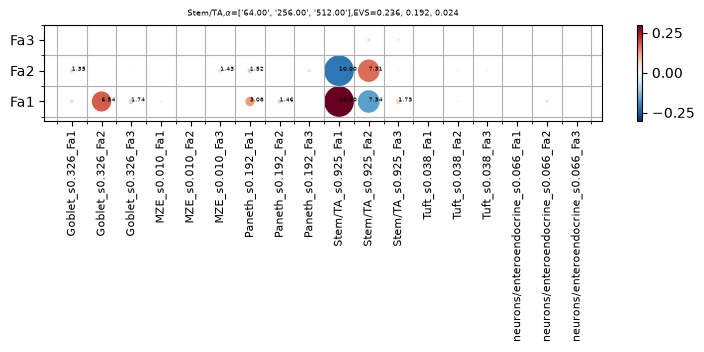

In [ ]:
from nico import Covariations as scov
from nico_wrapper.covariation import require_nico_covariation_state

# plot_regression_covariations() wraps this but doesn't expose mention_pvalue/figsize,
# so we load the NiCo state directly and call the underlying function.
_state = require_nico_covariation_state(covariation_result)

scov.plot_significant_regression_covariations_as_circleplot(
    _state,
    choose_celltypes=["Stem/TA"],
    mention_pvalue=True,
    pvalue_cutoff=0.05,
    dpi=300,
    saveas="png",
    transparent_mode=False,
    showit=True,
    figsize=(6, 1.25),
)

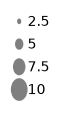

In [ ]:
from nico import Covariations as scov
from nico_wrapper.covariation import require_nico_covariation_state

# print_pvalue_sizebar() wrapper exists but doesn't expose number_of_dots_to_print/gray_level/figsize,
# so we load the NiCo state directly and call the underlying function.
_state = require_nico_covariation_state(covariation_result)

scov.print_pvalue_sizebar(
    _state,
    number_of_dots_to_print=4,
    gray_level=0.5,
    saveas="pdf",
    transparent_mode=False,
    showit=True,
    dpi=300,
    figsize=(0.68, 1.25),
)

cell types found  ['Stem/TA']
The regression figures as pvalue heatmap plots are saved in following path  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_coeff_heatmap_*


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_coeff_circleplot_10_Stem_TA.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_coeff_circleplot_11_Stem_TA.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_coeff_heatmap_10_Stem_TA.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_coeff_heatmap_11_Stem_TA.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_coeff_heatmap_7_Paneth.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/Regression_outputs/pvalue_coeff_heatmap_8_Paneth.png'))

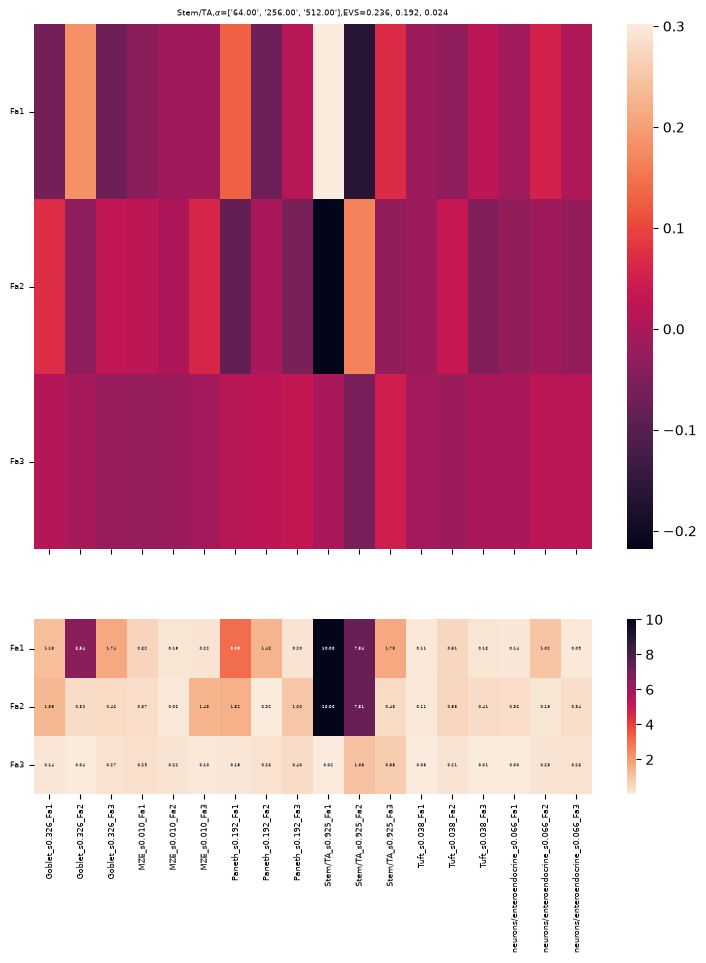

In [ ]:
from nico_wrapper.covariation.reports import plot_regression_covariations
from nico_wrapper.covariation.config import CovariationReportConfig

# Wrapper alternative for plot_significant_regression_covariations_as_heatmap.
# Note: figsize is not exposed by the wrapper.
plot_regression_covariations(
    covariation_result,
    kind="heatmap",
    config=CovariationReportConfig(
        choose_celltypes=("Stem/TA",),
        dpi=300,
        show=True,
        saveas="png",
        transparent=False,
    ),
)

One of the main questions is what happens when the two cell types are colocalized versus when they are not.
Do the differential gene expression profiles differ between colocalized cells and non-colocalized cells?
NiCo answer this using plotting factor loadings (as bar plots or violin plots) for a cell type when it is colocalized versus when it is not.

Total number of colocalized celltype pairs 214
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_scatter.png


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_as_BarPlot.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_as_ViolinPlot.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_scatter.png'))

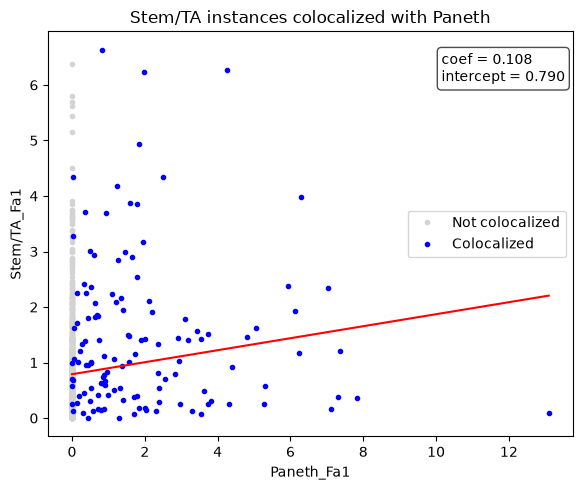

In [ ]:
from nico_wrapper.covariation.reports import plot_colocalized_factors
from nico_wrapper.covariation.config import CovariationReportConfig

# Visualize the change in factor loadings associated with colocalization between two cell types.
# Set include_bar=True and/or include_violin=True to generate all plots in a single call.
CC_name = "Stem/TA"
NC_name = "Paneth"
#CC_name = "Paneth"
#NC_name = "Stem/TA"


CC_factor_id = 1
#NC_factor_id = 2
NC_factor_id = 1

plot_colocalized_factors(
    covariation_result,
    central_cell_type=CC_name,
    neighbor_cell_type=NC_name,
    central_factor_id=CC_factor_id,
    neighbor_factor_id=NC_factor_id,
    include_bar=False,
    include_violin=False,
    config=CovariationReportConfig(
        show=True,
        saveas="png",
        dpi=300,
        transparent=False,
    ),
)

Total number of colocalized celltype pairs 214
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_scatter.png
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_as_BarPlot.png


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_as_BarPlot.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_as_ViolinPlot.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_scatter.png'))

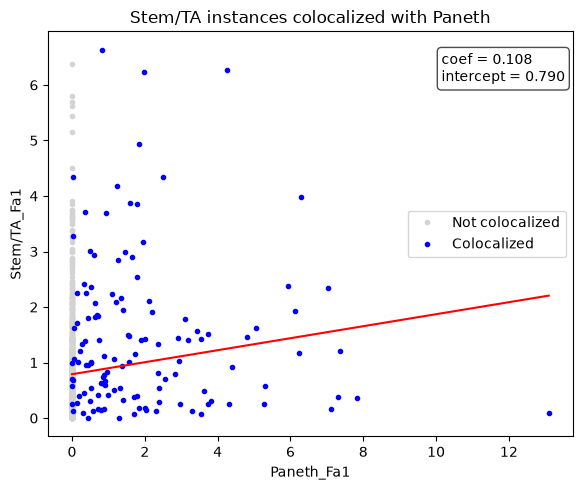

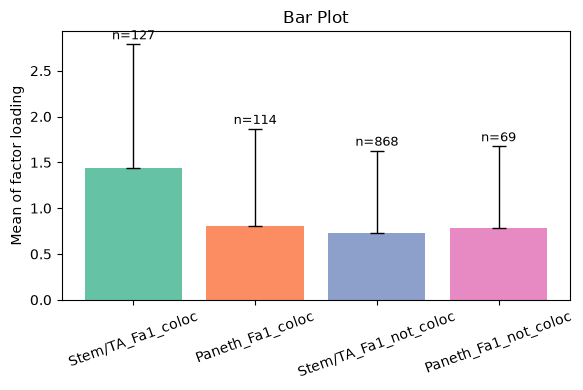

In [ ]:
from nico_wrapper.covariation.reports import plot_colocalized_factors
from nico_wrapper.covariation.config import CovariationReportConfig

# Bar plot: factor loadings of colocalized vs non-colocalized instances.
plot_colocalized_factors(
    covariation_result,
    central_cell_type=CC_name,
    neighbor_cell_type=NC_name,
    central_factor_id=CC_factor_id,
    neighbor_factor_id=NC_factor_id,
    include_bar=True,
    include_violin=False,
    config=CovariationReportConfig(
        show=True,
        saveas="png",
        dpi=300,
        transparent=False,
    ),
)

Total number of colocalized celltype pairs 214
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_scatter.png
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_as_ViolinPlot.png


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_as_BarPlot.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_as_ViolinPlot.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/colocalization/colocalize_celltypes_scatter.png'))

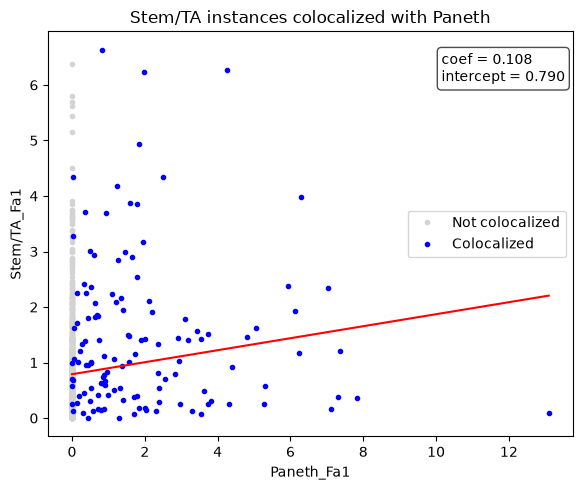

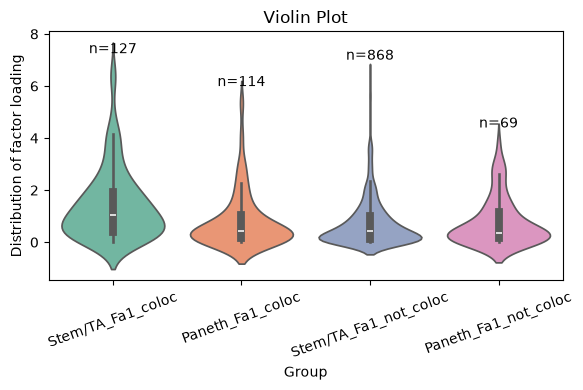

In [ ]:
from nico_wrapper.covariation.reports import plot_colocalized_factors
from nico_wrapper.covariation.config import CovariationReportConfig

# Violin plot: factor loadings of colocalized vs non-colocalized instances.
plot_colocalized_factors(
    covariation_result,
    central_cell_type=CC_name,
    neighbor_cell_type=NC_name,
    central_factor_id=CC_factor_id,
    neighbor_factor_id=NC_factor_id,
    include_bar=False,
    include_violin=True,
    config=CovariationReportConfig(
        show=True,
        saveas="png",
        dpi=300,
        transparent=False,
    ),
)

#### Analysis of ligand-receptor interactions
Take the ligand and receptor pairs that are covarying across interacting cell types (identified in step 6 niche intaraction analysis) and the factor loadings identified by the covariation analysis (step 7)

In [ ]:
from nico_wrapper.covariation.reports import plot_ligand_receptor_interactions
from nico_wrapper.covariation.config import CovariationReportConfig
from IPython.display import display, Image

# Ligand-receptor analysis
# Option 1: analysis between Stem/TA and Paneth cells for factors 1 and 1.
lr_paths = plot_ligand_receptor_interactions(
    covariation_result,
    choose_interacting_celltype_pair=("Stem/TA", "Paneth"),
    choose_factors_id=(1,1),
    config=CovariationReportConfig(
        pvalue_cutoff=0.05,
        ligand_factor_threshold=0.1, #Default is 0.3
        receptor_factor_threshold=0.1, #Default is 0.3
        ligand_population_threshold=0.2,
        receptor_population_threshold=0.2,
        dpi=150,
        show=False,   # nico closes figures before Jupyter captures them; display from file instead
        saveas="png",
        transparent=False,
    ),
)

# Display the saved plots inline
for p in lr_paths:
    display(Image(filename=str(p)))


In [ ]:
# Option 2: perform ligand-receptor analysis for Paneth cells and all the significant interaction partners
lr_paths2 = plot_ligand_receptor_interactions(
    covariation_result,
    choose_interacting_celltype_pair=("Paneth"),
    choose_factors_id=(),
    config=CovariationReportConfig(
        pvalue_cutoff=0.05,
        ligand_factor_threshold=0.1, #Default is 0.3
        receptor_factor_threshold=0.1, #Default is 0.3
        ligand_population_threshold=0.2,
        receptor_population_threshold=0.2,
        dpi=150,
        show=False,   # nico closes figures before Jupyter captures them; display from file instead
        saveas="png",
        transparent=False,
    ),
)

# Display the saved plots inline
for p in lr_paths2:
    display(Image(filename=str(p)))

#### Functional enrichment analysis for genes associated with latent factors

The pathway figures are saved in  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/Pathway_figures/
cell types found  ['Stem/TA']


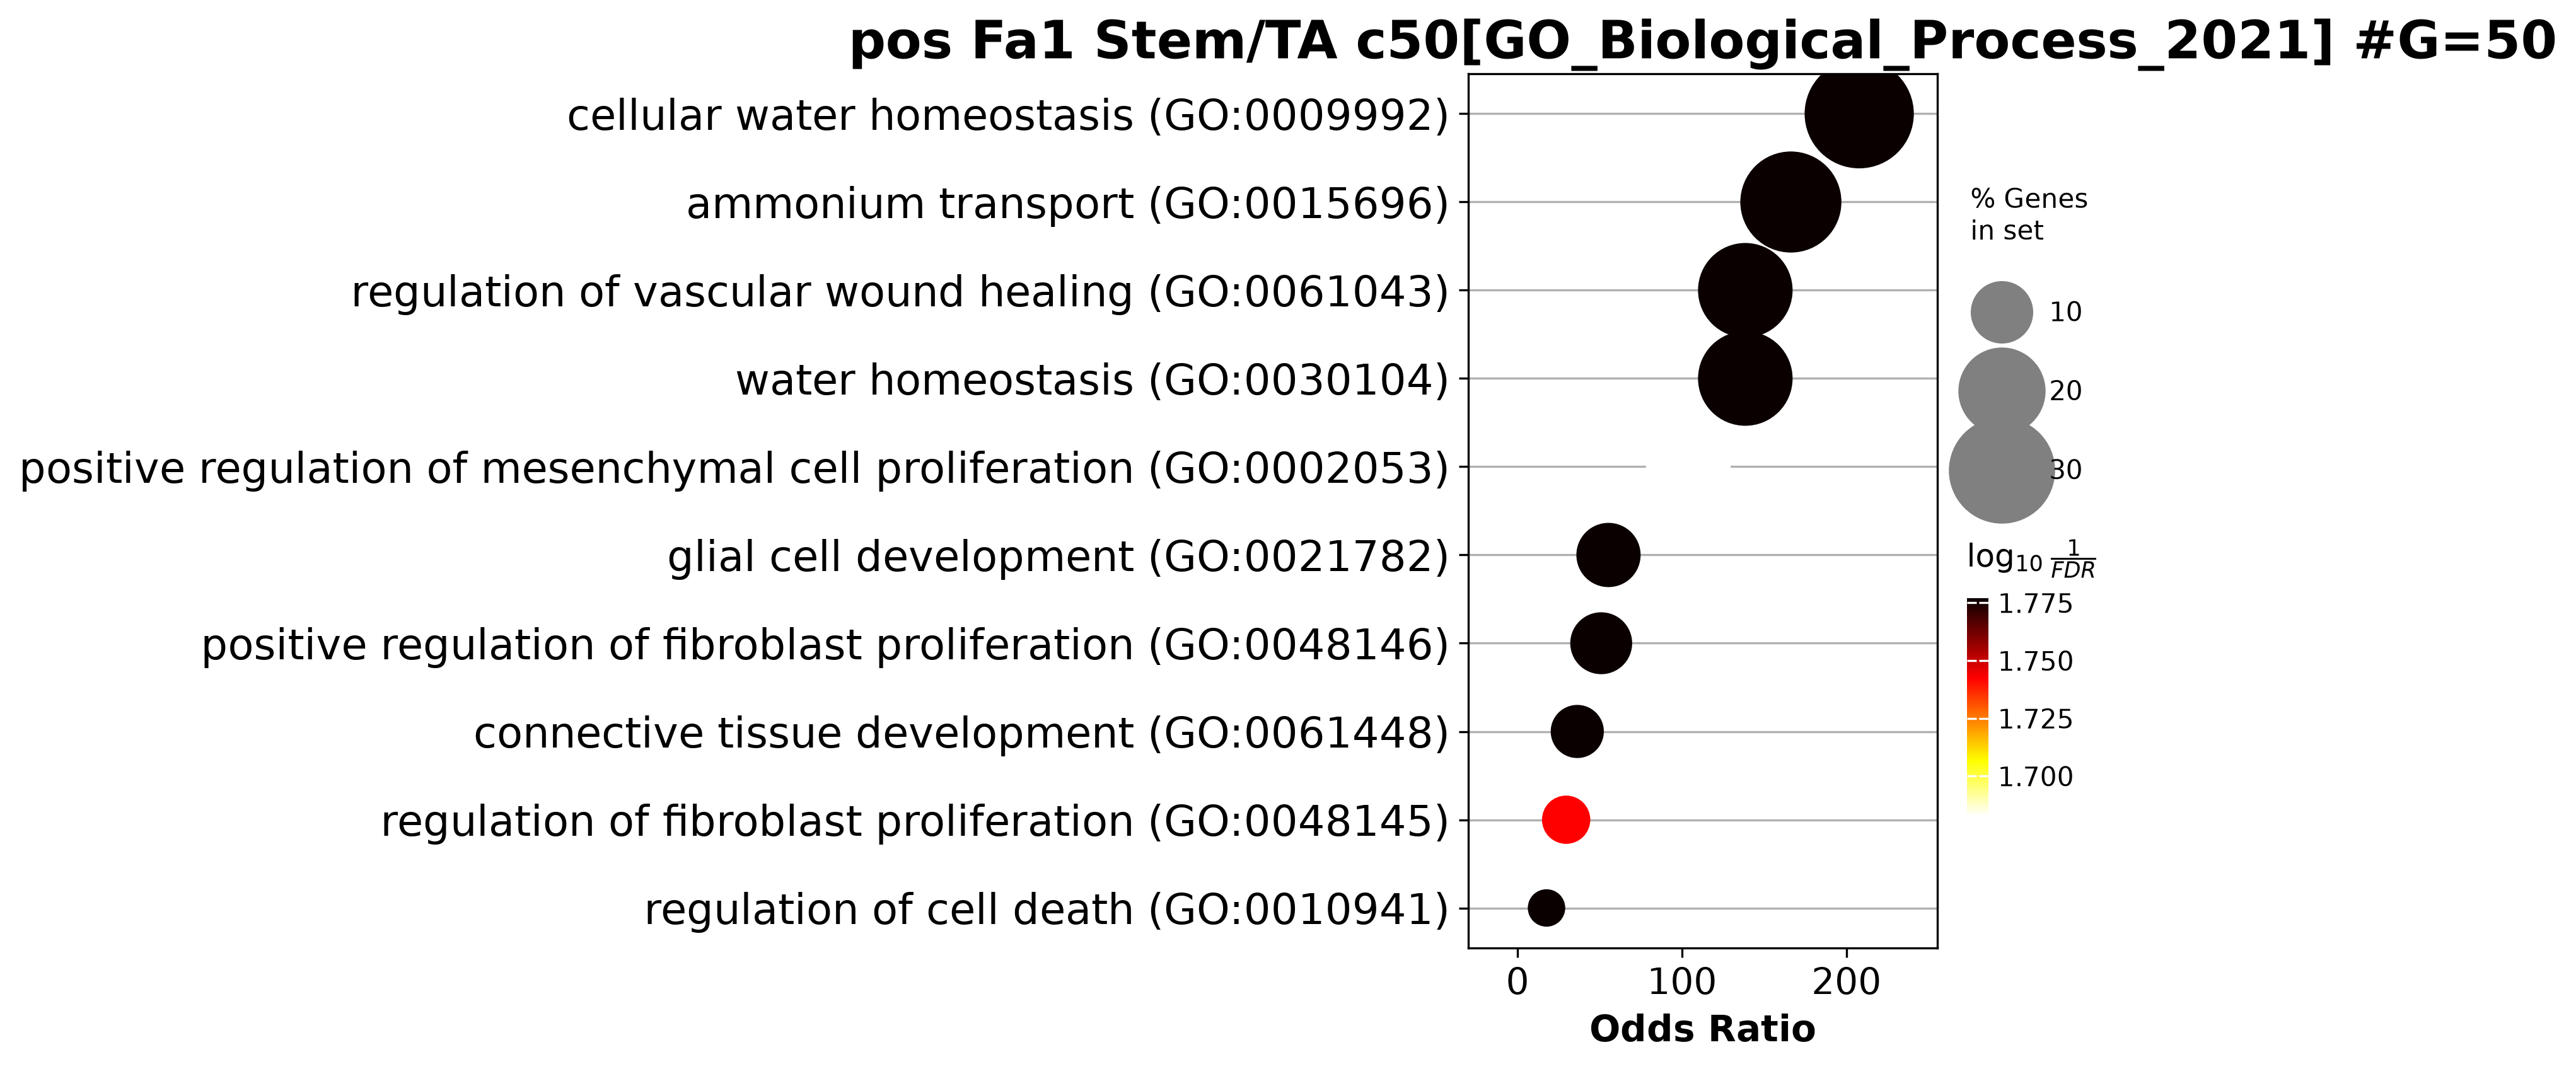

In [ ]:
from nico_wrapper.covariation.reports import run_pathway_enrichment
from nico_wrapper.covariation.config import CovariationReportConfig
from IPython.display import display, Image

# Note: circlesize, object_for_color, object_for_xaxis, fontsize, input_colormap
# are not exposed by the wrapper (cosmetic arguments only).
pathway_paths = run_pathway_enrichment(
    covariation_result,
    config=CovariationReportConfig(
        choose_celltypes=("Stem/TA",),
        choose_factors_id=(1,),
        pathway_top_genes=50,
        pathway_databases=("GO_Biological_Process_2021",),
        pathway_plot_as="dotplot",
        positively_correlated=True,
        include_rps_rpl_mt_genes=False,
        organism="mouse",
        correlation_with_spearman=True,
        show=False,   # display from saved file to ensure inline rendering
        saveas="png",
        dpi=150,
        transparent=False,
    ),
)

for p in pathway_paths:
    display(Image(filename=str(p)))

The pathway figures are saved in  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/Pathway_figures/
cell types found  ['Stem/TA']


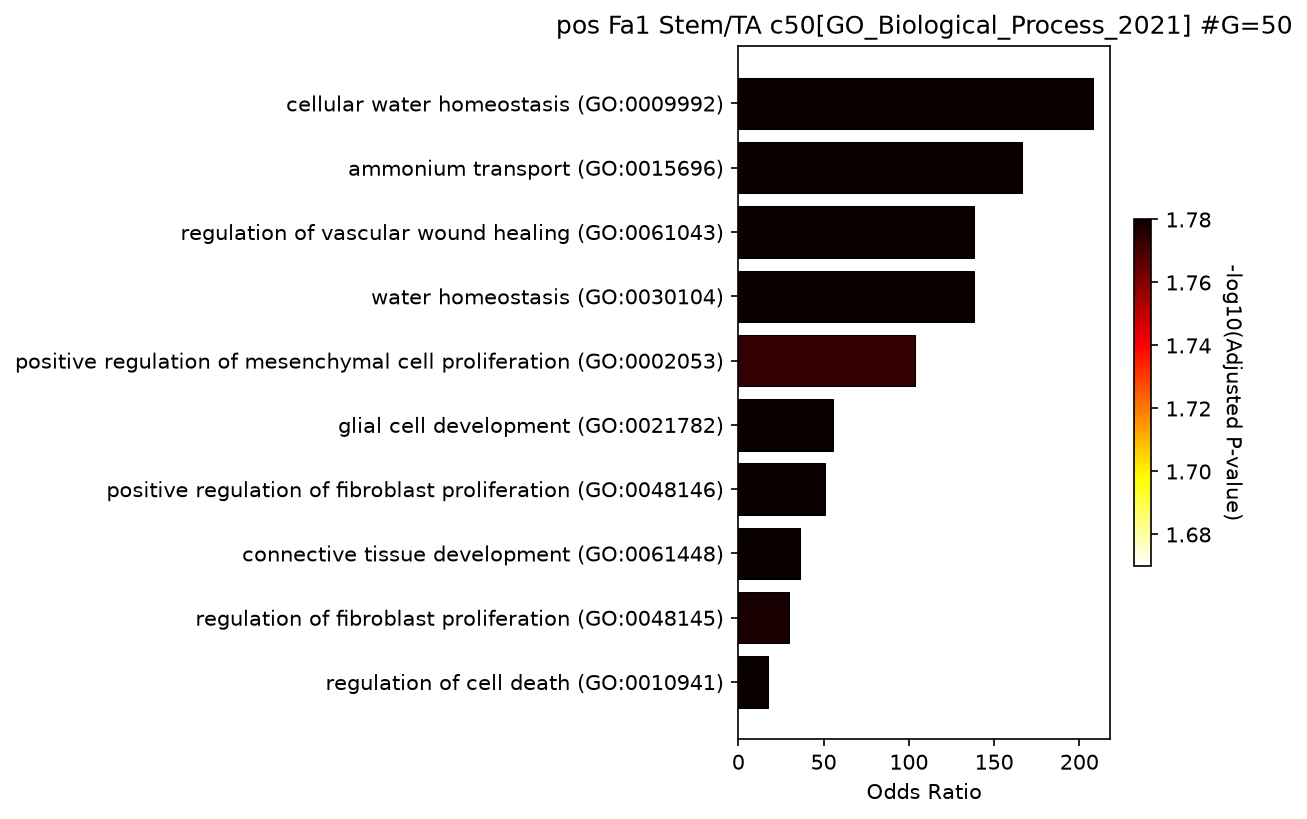

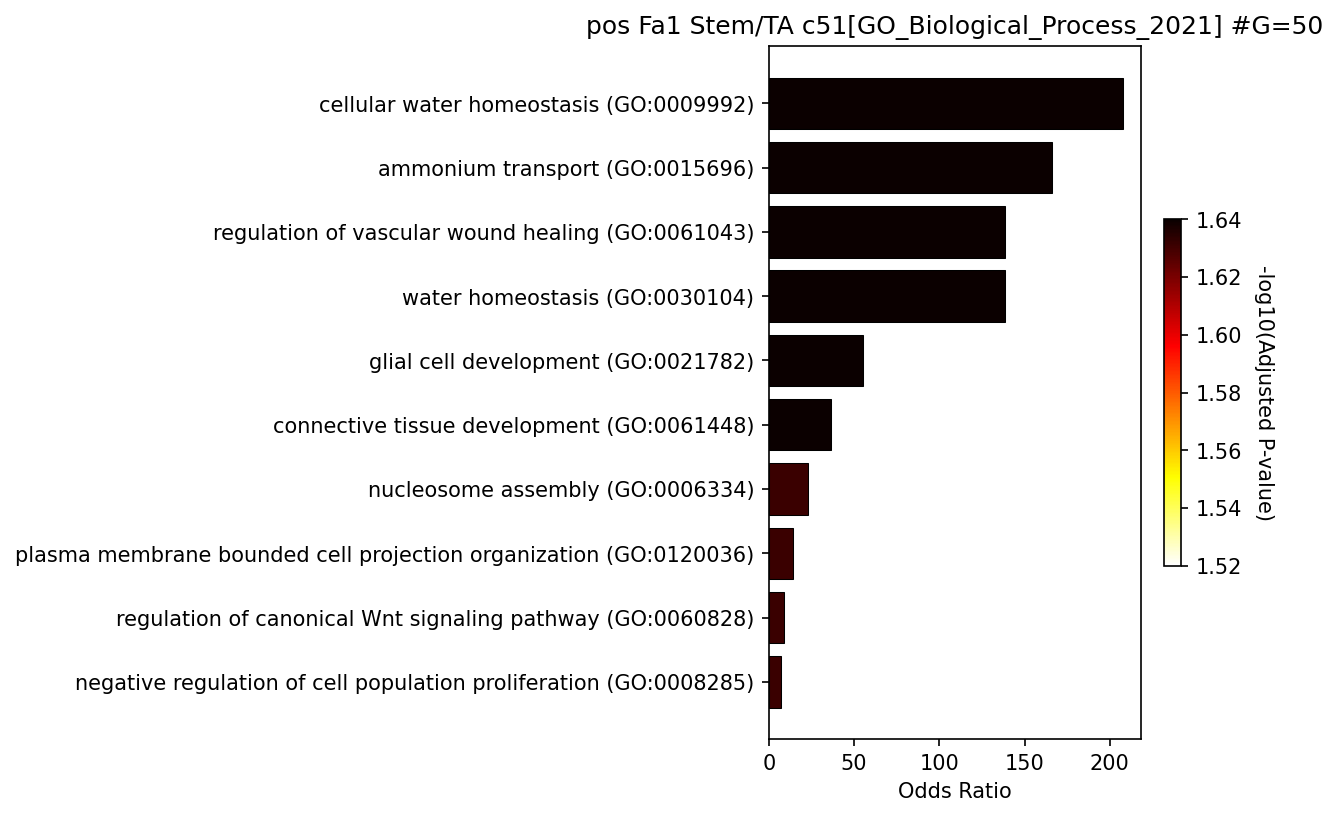

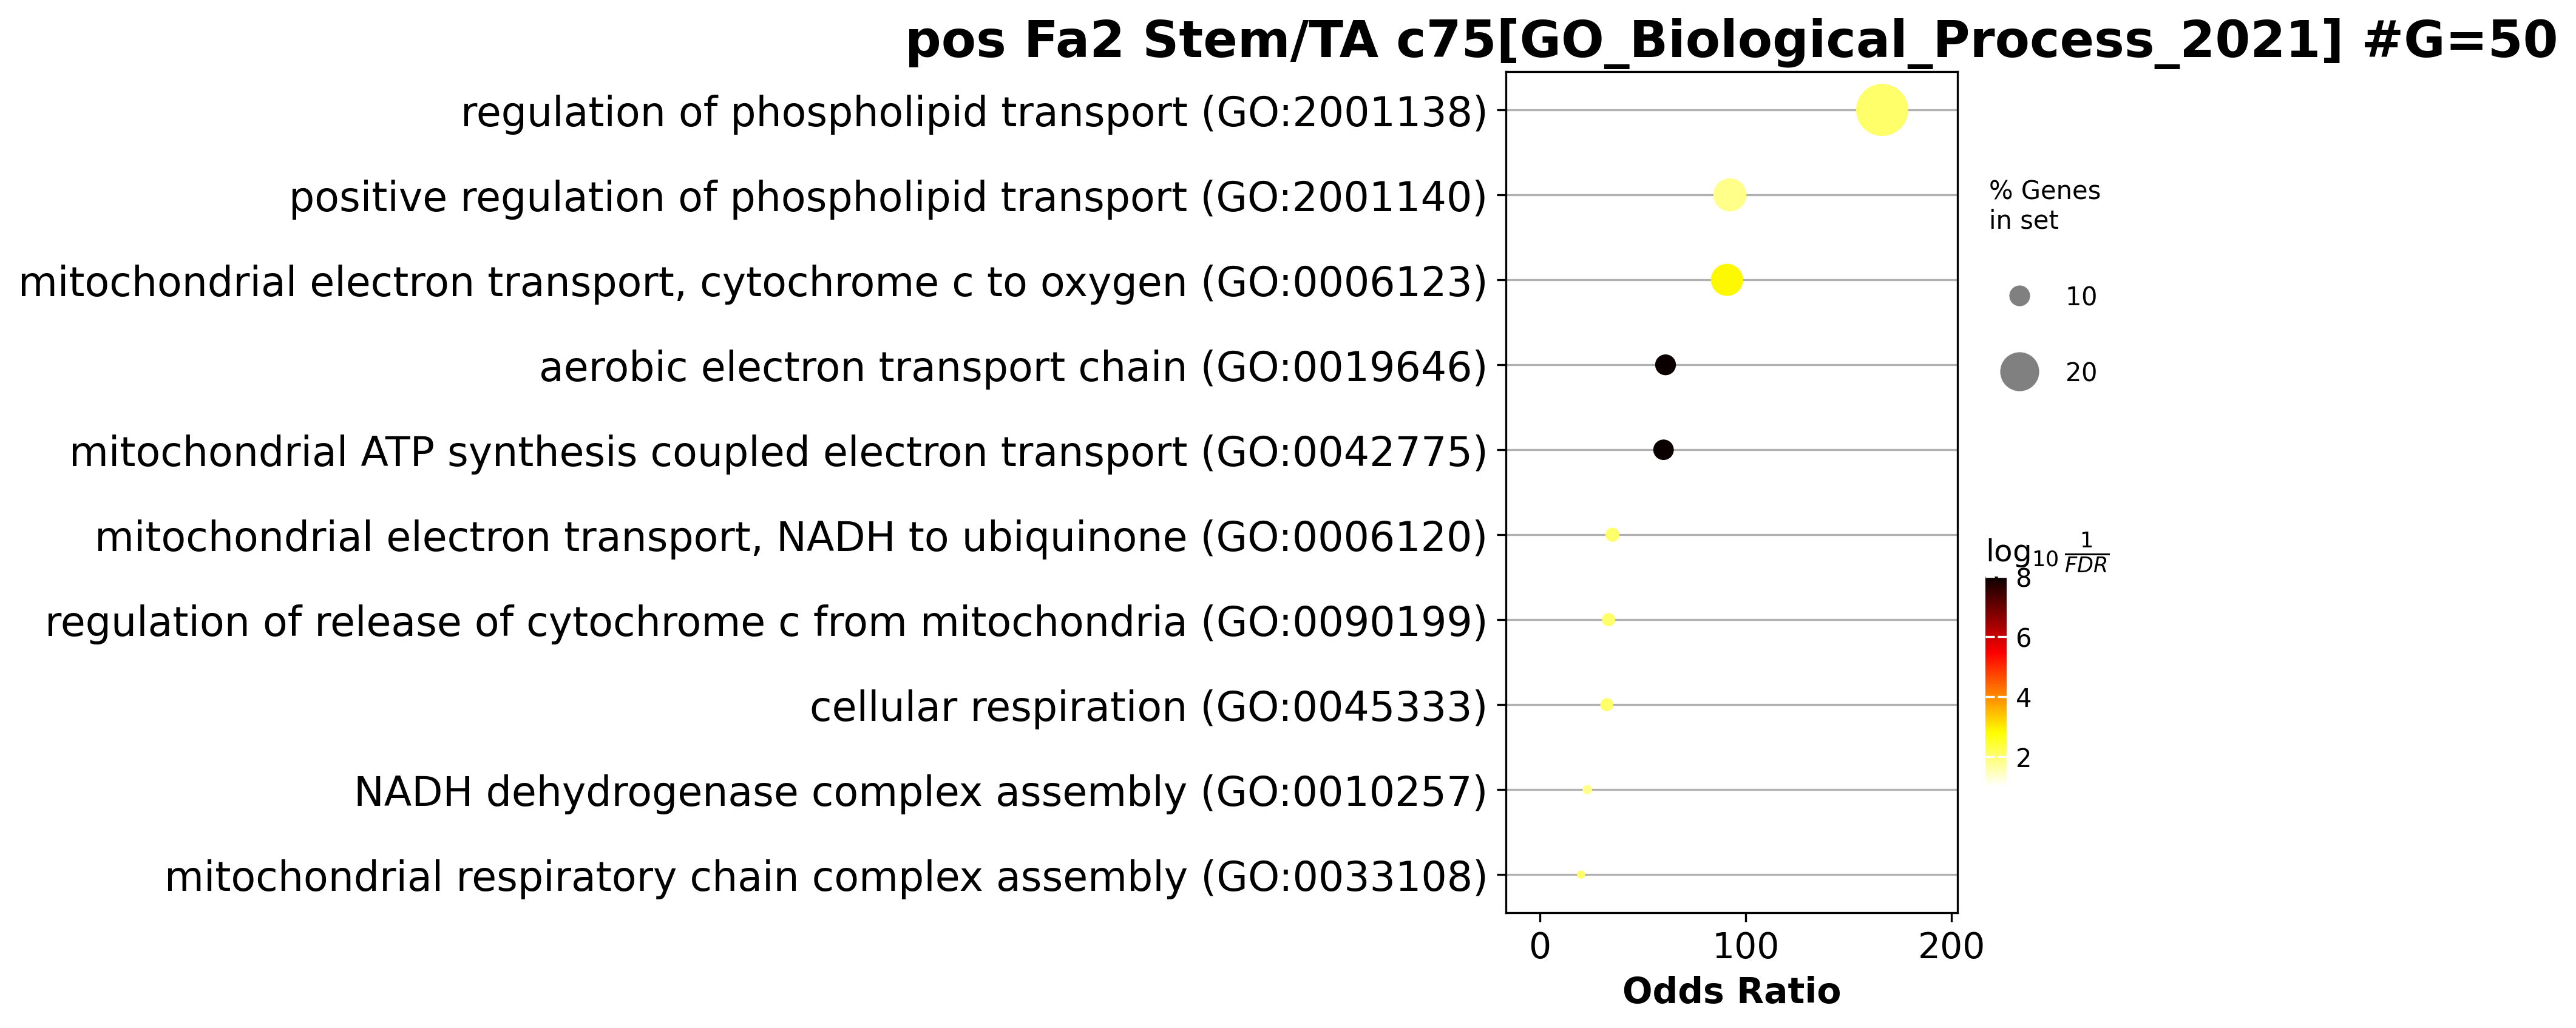

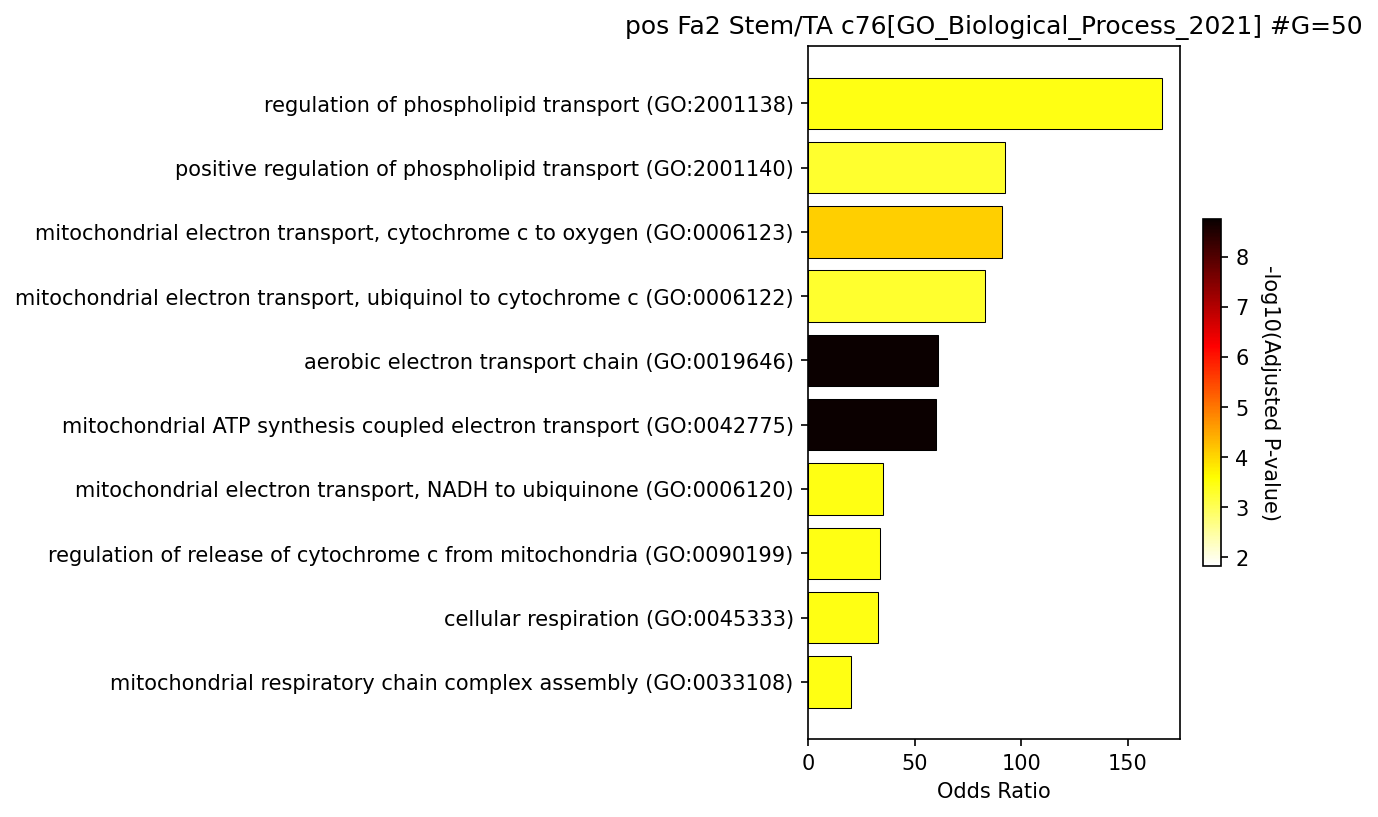

In [ ]:
#Barplot, instead of dotplot
pathway_paths = run_pathway_enrichment(
    covariation_result,
    config=CovariationReportConfig(
        choose_celltypes=("Stem/TA",),
        choose_factors_id=(1,),
        pathway_top_genes=50,
        pathway_databases=("GO_Biological_Process_2021",),
        pathway_plot_as="barplot",
        positively_correlated=True,
        include_rps_rpl_mt_genes=False,
        organism="mouse",
        correlation_with_spearman=True,
        show=False,   # display from saved file to ensure inline rendering
        saveas="png",
        dpi=150,
        transparent=False,
    ),
)

for p in pathway_paths:
    display(Image(filename=str(p)))

#### Additional plots
Visualization of top genes across cell types and factors as dotplot

cell types found  ['Paneth', 'Stem/TA']


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Paneth.png
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Stem_TA.png


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Factors_Stem_TA.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Paneth.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Stem_TA.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/combined_Stem_TA_Paneth.png'))

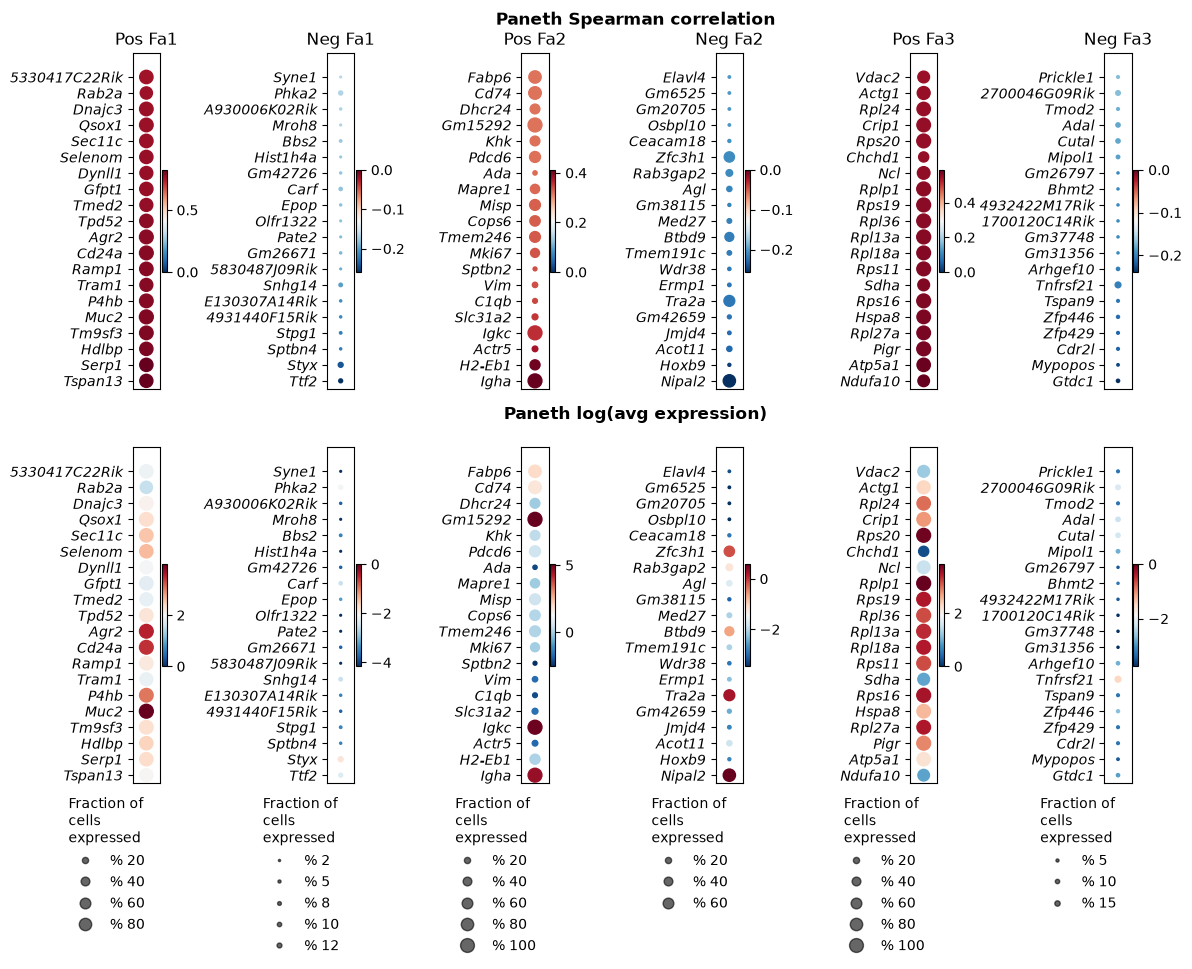

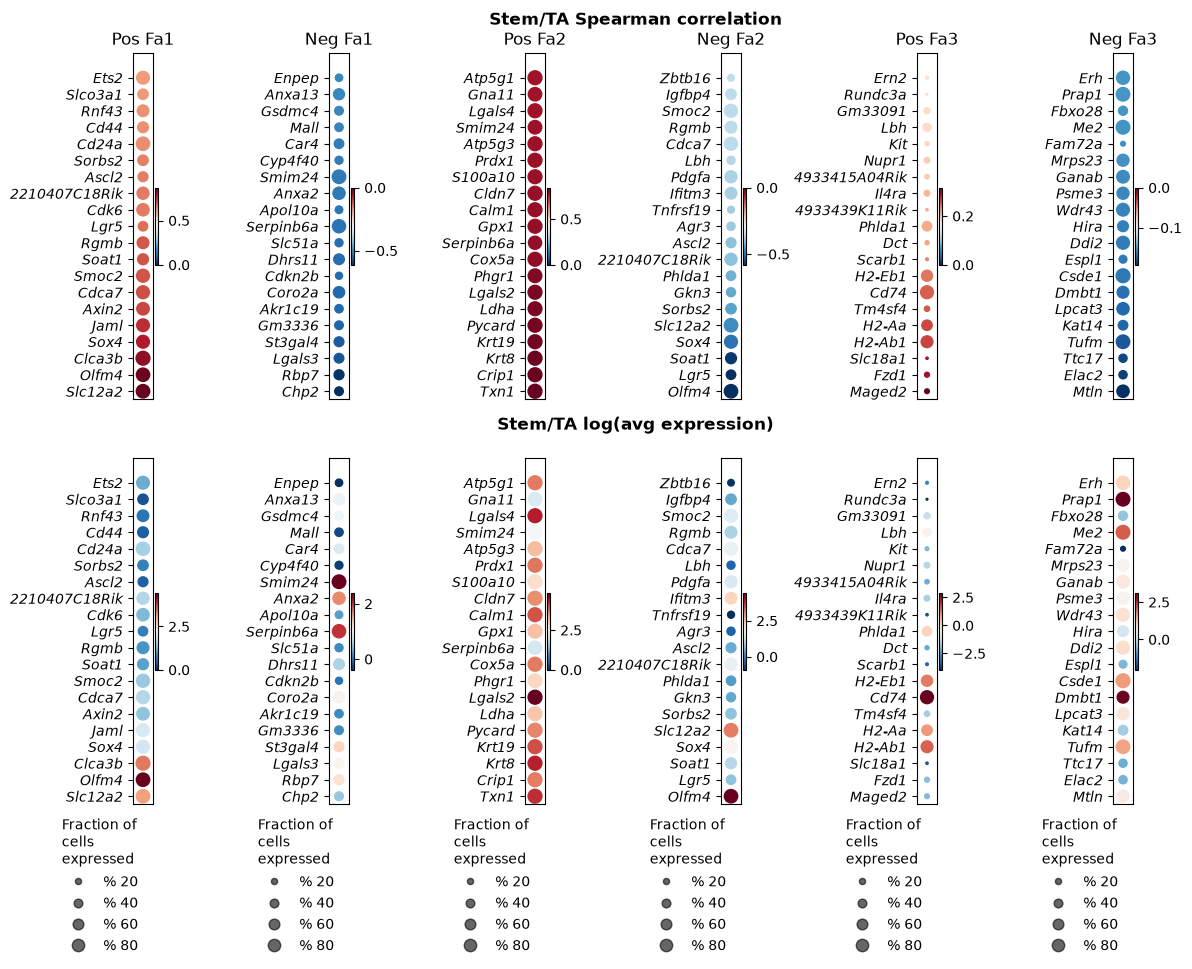

In [ ]:
from nico_wrapper.covariation.reports import plot_top_genes_all_factors
from nico_wrapper.covariation.config import CovariationReportConfig

# Top genes per factor for selected cell types (dot plots, one per cell type × factor).
plot_top_genes_all_factors(
    covariation_result,
    config=CovariationReportConfig(
        choose_celltypes=("Paneth", "Stem/TA"),
        top_genes_per_factor=20,
        organism="mouse",
        include_rps_rpl_mt_genes=True,
        correlation_with_spearman=True,
        show=True,
        saveas="png",
        dpi=150,
        transparent=False,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/combined_Stem_TA_Paneth.png


(PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Factors_Stem_TA.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Paneth.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/Stem_TA.png'),
 PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/dotplots/combined_Stem_TA_Paneth.png'))

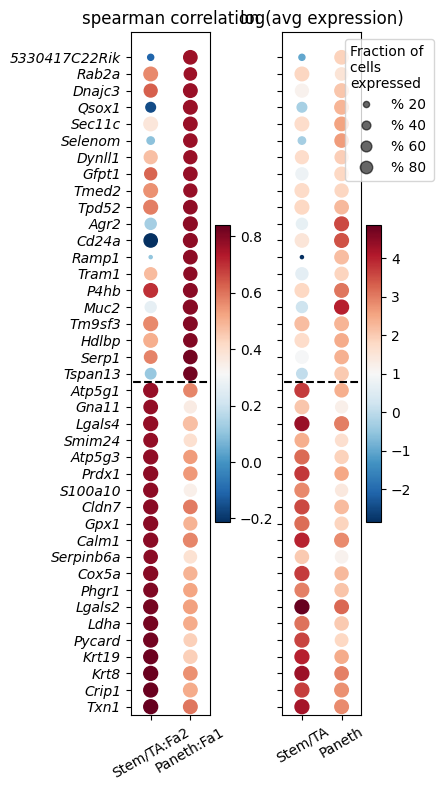

In [ ]:
from nico_wrapper.covariation.reports import plot_top_genes_pair
from nico_wrapper.covariation.config import CovariationReportConfig

# Top genes for a pair of cell types from two chosen factors.
plot_top_genes_pair(
    covariation_result,
    celltype_pair=("Stem/TA", "Paneth"),
    factor_ids=(2, 1),
    config=CovariationReportConfig(
        top_genes_per_factor=20,
        organism="mouse",
        include_rps_rpl_mt_genes=True,
        correlation_with_spearman=True,
        show=True,
        saveas="png",
        dpi=150,
        transparent=False,
    ),
)

Visualization of factor values in the UMAP

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/spatial_factors_in_umap.png


PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/spatial_factors_in_umap.png')

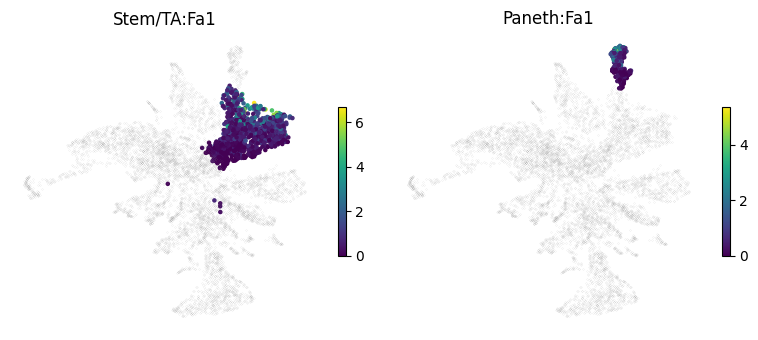

In [ ]:
from nico_wrapper.covariation.reports import plot_factor_umap
from nico_wrapper.covariation.config import CovariationReportConfig

# Spatial UMAP: factor loadings overlaid on spatial coordinates.
plot_factor_umap(
    covariation_result,
    modality="spatial",
    celltype_pair=("Stem/TA", "Paneth"),
    factor_ids=(1, 1),
    config=CovariationReportConfig(
        show=True,
        saveas="png",
        dpi=150,
        transparent=False,
    ),
)

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/scRNAseq_factors_in_umap.png


PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/scRNAseq_factors_in_umap.png')

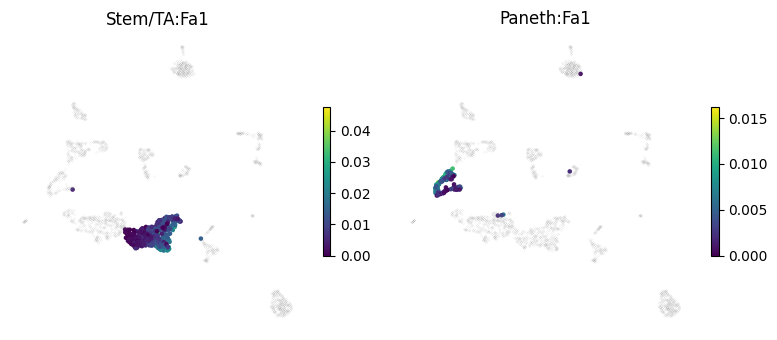

In [ ]:
from nico_wrapper.covariation.reports import plot_factor_umap
from nico_wrapper.covariation.config import CovariationReportConfig

# scRNAseq UMAP: factor loadings overlaid on scRNA-seq UMAP coordinates.
plot_factor_umap(
    covariation_result,
    modality="sc",
    celltype_pair=("Stem/TA", "Paneth"),
    factor_ids=(1, 1),
    config=CovariationReportConfig(
        show=True,
        saveas="png",
        dpi=150,
        transparent=False,
    ),
)

Visualization of one cell type at a time

The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/spatial_factors_in_umap.png
The figures are saved:  /home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/scRNAseq_factors_in_umap.png


PosixPath('/home/gruengroup/reyna/nico-wrapper/tests/nico_analysis/covariations_R0_F3/scRNAseq_factors_in_umap.png')

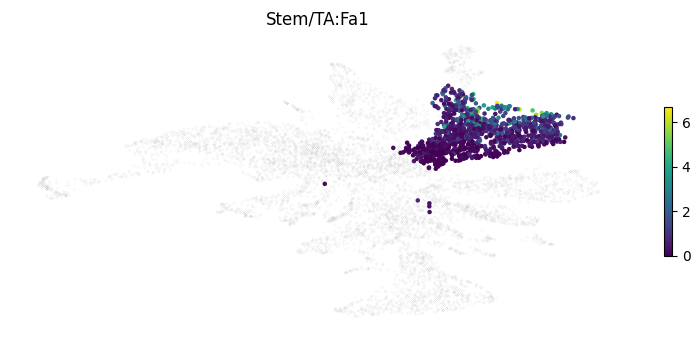

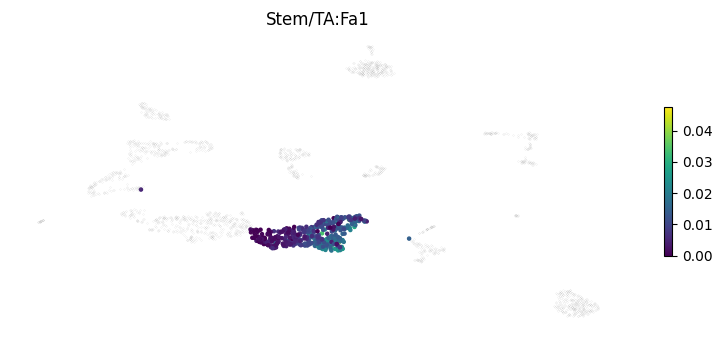

In [ ]:
from nico_wrapper.covariation.reports import plot_factor_umap
from nico_wrapper.covariation.config import CovariationReportConfig

_cfg = CovariationReportConfig(show=True, saveas="png", dpi=150, transparent=False)

# Spatial UMAP: single cell type / single factor.
plot_factor_umap(
    covariation_result,
    modality="spatial",
    celltype_pair=("Stem/TA",),
    factor_ids=(1,),
    config=_cfg,
)

# scRNAseq UMAP: single cell type / single factor.
plot_factor_umap(
    covariation_result,
    modality="sc",
    celltype_pair=("Stem/TA",),
    factor_ids=(1,),
    config=_cfg,
)

## 10. Additional Steps

| Task | Suggestion |
|------|------------|
| Refine cell-type annotation | Adjust `LabelTransferConfig` parameters and re-run label transfer |
| Try different neighbourhood radii | Re-run `run_niche_interactions` with different `radius` values |
| Gene-set enrichment on factors | Feed the regression table genes into GSEA / ORA tools |
| Custom visualisation | Load the interaction TSV / regression TSV into Seurat, Squidpy, or igraph |

Refer to the [API documentation](api.md) for the full parameter reference of every function used in this notebook.